In [1]:
from pathlib import Path
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *
plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


In [ ]:
# ── v2 classification datasheet, presented with v1 column names ───────────────
# The anatomy figures below were written against `cell_classifications_no_regions.csv`
# (v1: prospective/optimal-shift scores, old grid-score definition). They now read the
# v2 datasheet — all metrics recomputed at travel lag 0, bombcell good+mua curation,
# 500-spike floor, GC = grid score AND spatial information both beating their own
# shuffled null. Anatomy now ships with clark2025 itself, so no external
# brain-locations join is needed.
#
# This loader renames v2 columns to the v1 names the plotting code expects, so the
# figure code below is unchanged. Mapping:
#
#   SC_x/y/z                        <- coord_SCs_x/y/z      (verified identical, not negated)
#   brain_region                    <- brain_region          (verified identical)
#   cell_type   GC/NG/Other         <- gc_in + cell_class_of1/of2   (either-session rule,
#                                      matching v1, where GC = grid in EITHER session)
#   classified_by both/OF1/OF2/neither <- which sessions the cell was spatial in
#   firing_rate_OF1                 <- mean_rate_of1
#   grid_score_best                 <- max(grid_score_of1, grid_score_of2)
#   spatial_information_score_best  <- max(spatial_information_of1, of2)
#   spatial_information_score_of1   <- spatial_information_of1
#   travel                          <- 0.0 for every cell
#
# NOTE on the two "_best" columns: in v1 these were the scores at each cell's optimal
# prospective shift. That analysis has been dropped — everything is computed at lag 0 —
# so there is no "best" lag any more. They are mapped to the better of the two open-field
# sessions, which is the closest analogue under the either-session classification rule.
# `travel` is 0 everywhere for the same reason; any plot of travel is now degenerate.

CLS_V2_CSV = '/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications_v2.csv'

def load_classifications_v2(path=CLS_V2_CSV):
    d = pd.read_csv(path)
    c1, c2 = d['cell_class_of1'], d['cell_class_of2']
    testable = ~c1.isin(['EXCL', 'LOW']) | ~c2.isin(['EXCL', 'LOW'])
    d = d[testable].copy()
    c1, c2 = d['cell_class_of1'], d['cell_class_of2']

    sp1, sp2 = c1.isin(['GC', 'NGS']), c2.isin(['GC', 'NGS'])
    d['classified_by'] = np.select([sp1 & sp2, sp1, sp2], ['both', 'OF1', 'OF2'],
                                   default='neither')
    d['cell_type'] = np.where(d['gc_in'] != 'neither', 'GC',
                       np.where(d['classified_by'] != 'neither', 'NG', 'Other'))

    d['SC_x'], d['SC_y'], d['SC_z'] = d['coord_SCs_x'], d['coord_SCs_y'], d['coord_SCs_z']
    d['firing_rate_OF1'] = d.get('mean_rate_of1', np.nan)
    d['grid_score_best'] = d[['grid_score_of1', 'grid_score_of2']].max(axis=1)
    d['spatial_information_score_best'] = d[['spatial_information_of1',
                                             'spatial_information_of2']].max(axis=1)
    d['spatial_information_score_of1'] = d['spatial_information_of1']
    d['travel'] = 0.0
    return d

_CLS_V2 = load_classifications_v2()
print(f'v2 datasheet: {len(_CLS_V2)} cells  '
      f'{_CLS_V2.cell_type.value_counts().to_dict()}')
print(f'  classified_by: {_CLS_V2.classified_by.value_counts().to_dict()}')
print(f'  brain regions: {_CLS_V2.brain_region.value_counts().head(5).to_dict()}')


Loaded: 753 grid cells, 6795 NGS, 1627 other, 1536 contacts
Rendering 320° full brain (contacts)…


Could not update the latest atlas versions cache: [Errno 13] Permission denied: '/Users/harryclark/.brainglobe/last_versions.conf'


Saving new screenshot at /tmp/mec_renders/full_contacts.png

Rendering 0° posterior clipped (contacts)…


Could not update the latest atlas versions cache: [Errno 13] Permission denied: '/Users/harryclark/.brainglobe/last_versions.conf'


Saving new screenshot at /tmp/mec_renders/clip_contacts.png

Computing annotation overlays (100µm slices)…
  done


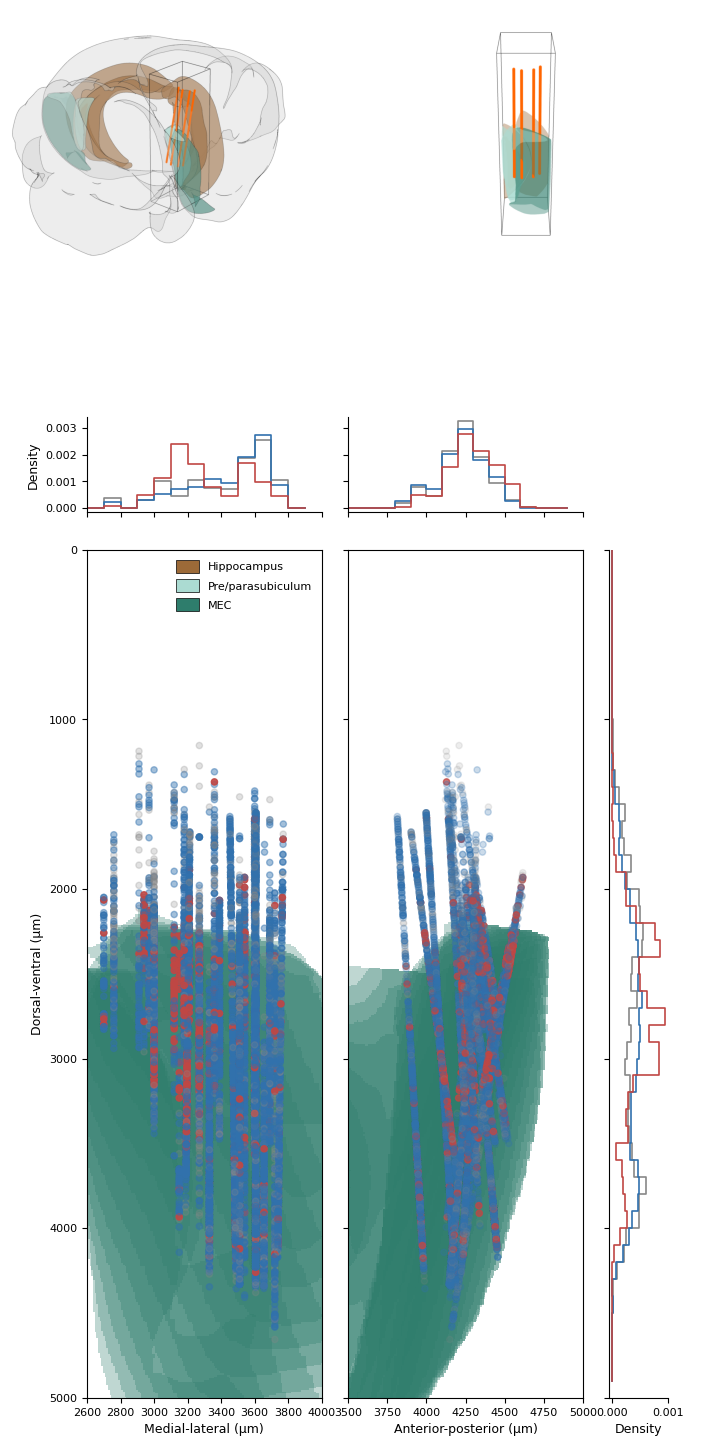

Saved → /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/mec_contacts_overview.pdf


In [1]:
from brainrender import Scene, settings as br_settings
from brainrender.actors import Points
from brainrender.actor import Actor
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgba
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import math
import re
from pathlib import Path
from vedo import Box as VedoBox
from tifffile import imread

br_settings.SHOW_AXES        = False
br_settings.BACKGROUND_COLOR = [1, 1, 1]

SAVE_DIR = Path('/tmp/mec_renders')
SAVE_DIR.mkdir(exist_ok=True)

annotations_set = imread('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/annotation.tiff')
structure_set = pd.read_csv('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/structures.csv')
id_to_acr = dict(zip(structure_set['id'], structure_set['acronym']))

TICK_SIZE  = 8
LABEL_SIZE = 9

def stereo_to_ccf(SC, angle=-0.0873):
    SC = np.asarray(SC, float)
    stretch = SC / np.array([1.0, 0.9434, 1.0])
    rotate = np.array([
        stretch[0]*math.cos(angle) - stretch[1]*math.sin(angle),
        stretch[0]*math.sin(angle) + stretch[1]*math.cos(angle),
        stretch[2]
    ])
    return rotate + np.array([5400.0, 440.0, 5700.0])

_df = load_classifications_v2()
_df = _df[_df['mouse'] != 22]
_df['SC_x'] = -np.abs(_df['SC_x'])

# Grid cells not split by classified_by (both/either merged into one group)
_gc    = _df[_df['cell_type'] == 'GC'].dropna(subset=['SC_x', 'SC_y', 'SC_z'])
_ngs   = _df[_df['cell_type'] == 'NG'].dropna(subset=['SC_x', 'SC_y', 'SC_z'])
_other = _df[~_df['cell_type'].isin(['GC', 'NG'])].dropna(subset=['SC_x', 'SC_y', 'SC_z'])

_dc = pd.read_csv('/Users/harryclark/Downloads/device_contact_id_annotations.csv')
_dc = _dc[_dc['mouse'] == 26]

def _dc_to_ccf(d):
    return np.array([stereo_to_ccf(r) for r in d[['coord_SCs_z', 'coord_SCs_y', 'coord_SCs_x']].values])

contact_pts = _dc_to_ccf(_dc)

def _df_to_ccf(d):
    return np.array([stereo_to_ccf(r) for r in d[['SC_z', 'SC_y', 'SC_x']].values])

gc_pts    = _df_to_ccf(_gc)    if len(_gc) > 0    else np.empty((0,3))
ngs_pts   = _df_to_ccf(_ngs)   if len(_ngs) > 0   else np.empty((0,3))
other_pts = _df_to_ccf(_other) if len(_other) > 0 else np.empty((0,3))

ml_gc = -_gc['SC_x'].values;       ml_ngs = -_ngs['SC_x'].values;       ml_other = -_other['SC_x'].values
dv_gc =  _gc['SC_y'].values;       dv_ngs =  _ngs['SC_y'].values;       dv_other =  _other['SC_y'].values
ap_gc =  _gc['SC_z'].values;       ap_ngs =  _ngs['SC_z'].values;       ap_other =  _other['SC_z'].values

print(f"Loaded: {len(_gc)} grid cells, {len(_ngs)} NGS, {len(_other)} other, {len(_dc)} contacts")

ML_LIM = (2600, 4000)
AP_LIM = (3500, 5000)
DV_LIM = (5000, 0)

corners_sc = np.array([
    [AP_LIM[0], min(DV_LIM), -ML_LIM[1]],
    [AP_LIM[0], min(DV_LIM), -ML_LIM[0]],
    [AP_LIM[0], max(DV_LIM), -ML_LIM[1]],
    [AP_LIM[0], max(DV_LIM), -ML_LIM[0]],
    [AP_LIM[1], min(DV_LIM), -ML_LIM[1]],
    [AP_LIM[1], min(DV_LIM), -ML_LIM[0]],
    [AP_LIM[1], max(DV_LIM), -ML_LIM[1]],
    [AP_LIM[1], max(DV_LIM), -ML_LIM[0]],
])
corners_ccf = np.array([stereo_to_ccf(c) for c in corners_sc])

bbox_min = corners_ccf.min(axis=0)
bbox_max = corners_ccf.max(axis=0)
bbox_center = (bbox_min + bbox_max) / 2
bbox_size   = bbox_max - bbox_min

FOCAL = (float(bbox_center[0]), float(bbox_center[1]), float(-bbox_center[2]))
rendered_bounds = [
    float(bbox_min[0]), float(bbox_max[0]),
    float(bbox_min[1]), float(bbox_max[1]),
    float(-bbox_max[2]), float(-bbox_min[2]),
]
bbox_center_rendered = (float(bbox_center[0]), float(bbox_center[1]), float(-bbox_center[2]))

def in_bbox(pts, bmin, bmax):
    return np.all((pts >= bmin) & (pts <= bmax), axis=1)

contact_box = contact_pts[in_bbox(contact_pts, bbox_min, bbox_max)]
gc_box      = gc_pts[in_bbox(gc_pts, bbox_min, bbox_max)]       if len(gc_pts) > 0    else np.empty((0,3))
ngs_box     = ngs_pts[in_bbox(ngs_pts, bbox_min, bbox_max)]     if len(ngs_pts) > 0   else np.empty((0,3))
other_box   = other_pts[in_bbox(other_pts, bbox_min, bbox_max)] if len(other_pts) > 0 else np.empty((0,3))

# ── Brain region colour scheme (matches mec_combined_tour.gif) ──────────────
COL_HIPPO   = '#9C6A38'   # hippocampus (CA + DG)
COL_PREPARA = '#ABDBD2'   # pre/parasubiculum (PRE + PAR)
COL_MEC     = '#2E7D6C'   # medial entorhinal cortex (ENTm)
STRUCT_REGIONS = [
    ('CA',   COL_HIPPO,   0.40),
    ('DG',   COL_HIPPO,   0.40),
    ('PRE',  COL_PREPARA, 0.40),
    ('PAR',  COL_PREPARA, 0.40),
    ('ENTm', COL_MEC,     0.40),
]
REGION_LEGEND = [
    ('Hippocampus', COL_HIPPO),
    ('Pre/parasubiculum', COL_PREPARA),
    ('MEC', COL_MEC),
]

R_horiz  = 35000
DV_ELEV  = -15000
R_close  = 12000
DV_close = -6000

# ── Cell-type colours ────────────────────────────────────────────────────────
COL_GC      = '#c04744'
COL_NGS     = '#3171ae'
COL_OTHER   = '#888888'
COL_CONTACT = '#ff6500'

def build_full_scene():
    scene = Scene(root=True, atlas_name='allen_mouse_10um', title='')
    for rname, color, alpha in STRUCT_REGIONS:
        try:
            scene.add_brain_region(rname, alpha=alpha, color=color)
        except Exception as e:
            print(f'  skipped {rname}: {e}')
    box = VedoBox(pos=tuple(bbox_center),
                  length=float(bbox_size[0]),
                  width=float(bbox_size[1]),
                  height=float(bbox_size[2]))
    box.wireframe().c('black').lw(3).alpha(1.0)
    scene.add(Actor(box, name='bbox', br_class='mesh'))
    scene.add(Points(contact_pts, name='contacts', colors=COL_CONTACT, radius=40, alpha=0.6))
    return scene

rad_320 = np.radians(320)
cam_full = {
    'pos':            (FOCAL[0] + R_horiz * np.cos(rad_320),
                       FOCAL[1] + DV_ELEV,
                       FOCAL[2] - R_horiz * np.sin(rad_320)),
    'focal_point':    FOCAL,
    'viewup':         (0, -1, 0),
    'clipping_range': (20000, 60000),
}

print("Rendering 320° full brain (contacts)…")
scene = build_full_scene()
scene.render(camera=cam_full, interactive=False, zoom=2)
scene.screenshot(name=str(SAVE_DIR / 'full_contacts'), scale=2)
try:
    scene.close()
except Exception:
    pass
img_full = mpimg.imread(str(SAVE_DIR / 'full_contacts.png'))

def build_clipped_scene():
    scene = Scene(root=False, atlas_name='allen_mouse_10um', title='')
    for rname, color, alpha in STRUCT_REGIONS:
        try:
            scene.add_brain_region(rname, alpha=alpha, color=color)
        except Exception as e:
            print(f'  skipped {rname}: {e}')
    if len(contact_box) > 0:
        scene.add(Points(contact_box, name='contacts', colors=COL_CONTACT, radius=40, alpha=0.6))
    return scene

cam_clip = {
    'pos':            (FOCAL[0] + R_close, FOCAL[1] + DV_close, FOCAL[2]),
    'focal_point':    FOCAL,
    'viewup':         (0, -1, 0),
    'clipping_range': (5000, 25000),
}

print("Rendering 0° posterior clipped (contacts)…")
scene = build_clipped_scene()
scene.render(camera=cam_clip, interactive=False, zoom=1)
for a in scene.plotter.objects:
    try:
        a.cut_with_box(rendered_bounds)
    except Exception:
        pass
box = VedoBox(pos=bbox_center_rendered,
              length=float(bbox_size[0]),
              width=float(bbox_size[1]),
              height=float(bbox_size[2]))
box.wireframe().c('black').lw(3).alpha(1.0)
scene.plotter.add(box)
scene.plotter.window.Render()
scene.screenshot(name=str(SAVE_DIR / 'clip_contacts'), scale=2)
try:
    scene.close()
except Exception:
    pass
img_clip = mpimg.imread(str(SAVE_DIR / 'clip_contacts.png'))

print("Computing annotation overlays (100µm slices)…")

step = 10
ml_axis = np.arange(ML_LIM[0] - 100, ML_LIM[1] + 100, step)
dv_axis = np.arange(min(DV_LIM) - 100, max(DV_LIM) + 100, step)
ap_axis = np.arange(AP_LIM[0] - 100, AP_LIM[1] + 100, step)

ap_slices = list(range(AP_LIM[0], AP_LIM[1] + 1, 100))
ml_slices = list(range(ML_LIM[0], ML_LIM[1] + 1, 100))

def _stereo_to_ccf_vec(ap, dv, ml, angle=-0.0873):
    cos_a, sin_a = math.cos(angle), math.sin(angle)
    s_dv = dv / 0.9434
    return (ap * cos_a - s_dv * sin_a + 5400.0,
            ap * sin_a + s_dv * cos_a + 440.0,
            ml + 5700.0)

# region categories: 1 = Hippocampus (CA/DG), 2 = Pre/Parasubiculum (PRE/PAR), 3 = MEC (ENTm)
_RE_HIPPO   = re.compile(r'^(CA[1-4]?|DG)(-|$)')
_RE_PREPARA = re.compile(r'^(PRE|PAR)\d*$')
_RE_MEC     = re.compile(r'^ENTm')

def _ids_to_numeric(aid_flat):
    numeric = np.zeros(len(aid_flat), dtype=int)
    for sid in np.unique(aid_flat):
        if sid == 0:
            continue
        acr = id_to_acr.get(sid, 'root')
        m = aid_flat == sid
        if _RE_HIPPO.match(acr):
            numeric[m] = 1
        elif _RE_PREPARA.match(acr):
            numeric[m] = 2
        elif _RE_MEC.match(acr):
            numeric[m] = 3
    return numeric

def _lookup_slice_numeric(ccf_ap, ccf_dv, ccf_ml, shape_2d):
    zi = np.round(ccf_ap / 10).astype(int)
    yi = np.round(ccf_dv / 10).astype(int)
    xi = np.round(ccf_ml / 10).astype(int)
    sh = annotations_set.shape
    valid = (zi >= 0) & (zi < sh[0]) & (yi >= 0) & (yi < sh[1]) & (xi >= 0) & (xi < sh[2])
    aid = np.zeros(len(zi), dtype=int)
    aid[valid] = annotations_set[zi[valid], yi[valid], xi[valid]]
    return _ids_to_numeric(aid).reshape(shape_2d)

def get_ap_slice(ap_val):
    DV, ML = np.meshgrid(dv_axis, ml_axis, indexing='ij')
    c_ap, c_dv, c_ml = _stereo_to_ccf_vec(np.full(DV.size, ap_val), DV.ravel(), ML.ravel())
    return _lookup_slice_numeric(c_ap, c_dv, c_ml, DV.shape)

def get_ml_slice(ml_val):
    AP, DV = np.meshgrid(ap_axis, dv_axis, indexing='ij')
    c_ap, c_dv, c_ml = _stereo_to_ccf_vec(AP.ravel(), DV.ravel(), np.full(AP.size, ml_val))
    return _lookup_slice_numeric(c_ap, c_dv, c_ml, AP.shape)

print("  done")

cmap_list = [(1, 1, 1, 0)]
for hexcol in [COL_HIPPO, COL_PREPARA, COL_MEC]:
    r, g, b, _ = to_rgba(hexcol)
    cmap_list.append((r, g, b, 0.30))
region_cmap = ListedColormap(cmap_list)
region_norm = BoundaryNorm(np.arange(-0.5, 3.5, 1), region_cmap.N)

DATA_ASPECT = (max(DV_LIM) - min(DV_LIM)) / (ML_LIM[1] - ML_LIM[0])
HIST_W = 0.25
HIST_H = 0.4

fig_w = 7
bot_panel_w = 0.85 * fig_w
bot_panel_h = bot_panel_w * (HIST_H + DATA_ASPECT) / (2 + HIST_W)
brain_h = 5.0
fig_h = brain_h + 0.4 + bot_panel_h

brain_top = 0.98
brain_bot = brain_top - brain_h / fig_h
bot_top = brain_bot - 0.3 / fig_h
bot_bot = 0.03

fig = plt.figure(figsize=(fig_w, fig_h))

top_gs = fig.add_gridspec(1, 2, wspace=0.02,
                          left=0.01, right=0.99, top=brain_top, bottom=brain_bot)
fig.add_subplot(top_gs[0]).imshow(img_full); fig.axes[-1].axis('off')
fig.add_subplot(top_gs[1]).imshow(img_clip); fig.axes[-1].axis('off')

bot_gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1, 1, HIST_W],
    height_ratios=[HIST_H, DATA_ASPECT],
    wspace=0.15, hspace=0.08,
    left=0.12, right=0.95, top=bot_top, bottom=bot_bot,
)

ax_ml_dv = fig.add_subplot(bot_gs[1, 0])
ax_ap_dv = fig.add_subplot(bot_gs[1, 1], sharey=ax_ml_dv)
ax_ml_h  = fig.add_subplot(bot_gs[0, 0], sharex=ax_ml_dv)
ax_ap_h  = fig.add_subplot(bot_gs[0, 1], sharex=ax_ap_dv, sharey=ax_ml_h)
ax_dv_h  = fig.add_subplot(bot_gs[1, 2], sharey=ax_ml_dv)
ax_blank = fig.add_subplot(bot_gs[0, 2])

for ap_val in ap_slices:
    s = get_ap_slice(ap_val)
    ax_ml_dv.pcolormesh(ml_axis, dv_axis, s,
                        cmap=region_cmap, norm=region_norm,
                        shading='nearest', rasterized=True)

# ── Interleave cell types randomly so no single type is systematically drawn on top ──
_rng = np.random.default_rng(0)

def scatter_interleaved(ax, entries):
    """entries: list of (x, y, color, size, alpha) tuples, one per cell type."""
    xs, ys, cs, ss = [], [], [], []
    for x, y, color, size, alpha in entries:
        if len(x) == 0:
            continue
        rgba = to_rgba(color, alpha=alpha)
        xs.append(x)
        ys.append(y)
        cs.append(np.tile(np.array(rgba), (len(x), 1)))
        ss.append(np.full(len(x), size))
    if not xs:
        return
    xs = np.concatenate(xs); ys = np.concatenate(ys)
    cs = np.concatenate(cs); ss = np.concatenate(ss)
    order = _rng.permutation(len(xs))
    ax.scatter(xs[order], ys[order], color=cs[order], s=ss[order], zorder=2)

scatter_interleaved(ax_ml_dv, [
    (ml_other, dv_other, COL_OTHER, 20, 0.25),
    (ml_ngs,   dv_ngs,   COL_NGS,   20, 0.45),
    (ml_gc,    dv_gc,    COL_GC,    20, 0.90),
])
ax_ml_dv.set_xlim(ML_LIM)
ax_ml_dv.set_ylim(DV_LIM)
ax_ml_dv.set_xlabel('Medial-lateral (µm)', fontsize=LABEL_SIZE)
ax_ml_dv.set_ylabel('Dorsal-ventral (µm)', fontsize=LABEL_SIZE)
ax_ml_dv.tick_params(labelsize=TICK_SIZE)

region_legend = [Patch(facecolor=c, edgecolor='black', lw=0.5, label=l) for l, c in REGION_LEGEND]
ax_ml_dv.legend(handles=region_legend, fontsize=8, frameon=False, loc='upper right',
                handlelength=2, handleheight=1.5, labelspacing=0.5)

for ml_val in ml_slices:
    s = get_ml_slice(ml_val)
    ax_ap_dv.pcolormesh(ap_axis, dv_axis, s.T,
                        cmap=region_cmap, norm=region_norm,
                        shading='nearest', rasterized=True)

scatter_interleaved(ax_ap_dv, [
    (ap_other, dv_other, COL_OTHER, 20, 0.15),
    (ap_ngs,   dv_ngs,   COL_NGS,   20, 0.25),
    (ap_gc,    dv_gc,    COL_GC,    20, 0.75),
])
ax_ap_dv.set_xlim(AP_LIM)
ax_ap_dv.set_xlabel('Anterior-posterior (µm)', fontsize=LABEL_SIZE)
ax_ap_dv.tick_params(labelleft=False, labelsize=TICK_SIZE)

ml_bins = np.arange(ML_LIM[0], ML_LIM[1] + 1, 100)
ax_ml_h.step(ml_bins[:-1], np.histogram(ml_other, ml_bins, density=True)[0],
             where='post', color=COL_OTHER, lw=1.2)
ax_ml_h.step(ml_bins[:-1], np.histogram(ml_ngs, ml_bins, density=True)[0],
             where='post', color=COL_NGS, lw=1.2)
ax_ml_h.step(ml_bins[:-1], np.histogram(ml_gc, ml_bins, density=True)[0],
             where='post', color=COL_GC, lw=1.2)
ax_ml_h.set_ylabel('Density', fontsize=LABEL_SIZE)
ax_ml_h.tick_params(labelbottom=False, labelsize=TICK_SIZE)
ax_ml_h.spines[['top', 'right']].set_visible(False)

ap_bins = np.arange(AP_LIM[0], AP_LIM[1] + 1, 100)
ax_ap_h.step(ap_bins[:-1], np.histogram(ap_other, ap_bins, density=True)[0],
             where='post', color=COL_OTHER, lw=1.2)
ax_ap_h.step(ap_bins[:-1], np.histogram(ap_ngs, ap_bins, density=True)[0],
             where='post', color=COL_NGS, lw=1.2)
ax_ap_h.step(ap_bins[:-1], np.histogram(ap_gc, ap_bins, density=True)[0],
             where='post', color=COL_GC, lw=1.2)
ax_ap_h.tick_params(labelbottom=False, labelleft=False, labelsize=TICK_SIZE)
ax_ap_h.spines[['top', 'right']].set_visible(False)

dv_bins = np.arange(min(DV_LIM), max(DV_LIM) + 1, 100)
ax_dv_h.step(np.histogram(dv_other, dv_bins, density=True)[0], dv_bins[:-1],
             where='post', color=COL_OTHER, lw=1.2)
ax_dv_h.step(np.histogram(dv_ngs, dv_bins, density=True)[0], dv_bins[:-1],
             where='post', color=COL_NGS, lw=1.2)
ax_dv_h.step(np.histogram(dv_gc, dv_bins, density=True)[0], dv_bins[:-1],
             where='post', color=COL_GC, lw=1.2)
ax_dv_h.set_xlabel('Density', fontsize=LABEL_SIZE)
ax_dv_h.tick_params(labelleft=False, labelsize=TICK_SIZE)
ax_dv_h.spines[['top', 'right']].set_visible(False)

ax_blank.axis('off')

out_path = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/mec_contacts_overview.pdf'
plt.savefig(out_path, bbox_inches='tight', dpi=1000)
plt.show()
print(f"Saved → {out_path}")


Loaded: 753 grid cells, 6795 NGS, 1627 other
[diagnostic] a fully-free (ML-rotating) best fit would still want 6.8° more tilt beyond the AP-DV-plane fit used above (which keeps the full ML axis exactly fixed — no left/right rotation)
Best-fit plane: -4.1° from pure coronal, AP = 9899 µm, plane normal: (1.00, -0.07, 0.00), centroid: (9899, 3262, 2276) µm, variance explained: 96.3%
Rendering 320° full brain (all cells + best-fit slice plane)…


Could not update the latest atlas versions cache: [Errno 13] Permission denied: '/Users/harryclark/.brainglobe/last_versions.conf'


Saving new screenshot at /tmp/mec_renders/full_cells.png

Sampling annotation volume along the best-fit plane…
  done


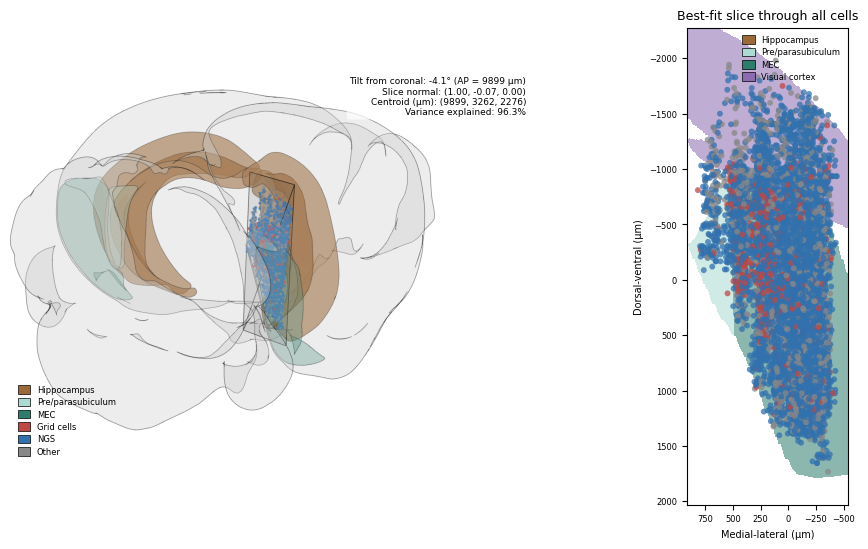

Saved → /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/mec_cells_3d_overview.pdf


In [1]:
from brainrender import Scene, settings as br_settings
from brainrender.actors import Points
from brainrender.actor import Actor
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import math
import re
from pathlib import Path
from vedo import Mesh as VedoMesh
from tifffile import imread

br_settings.SHOW_AXES        = False
br_settings.BACKGROUND_COLOR = [1, 1, 1]

# Cells within a shank are currently plotted at one nominal ML coordinate, producing
# unrealistic vertical stripes. This adds Gaussian jitter (µm, stdev) to each cell's
# ML position as a stand-in for the spread expected once refined per-cell ML locations
# are computed. Set to 0 to disable.
ML_JITTER_STD = 40.0

SAVE_DIR = Path('/tmp/mec_renders')
SAVE_DIR.mkdir(exist_ok=True)

annotations_set = imread('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/annotation.tiff')
structure_set = pd.read_csv('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/structures.csv')
id_to_acr = dict(zip(structure_set['id'], structure_set['acronym']))

def stereo_to_ccf(SC, angle=-0.0873):
    SC = np.asarray(SC, float)
    stretch = SC / np.array([1.0, 0.9434, 1.0])
    rotate = np.array([
        stretch[0]*math.cos(angle) - stretch[1]*math.sin(angle),
        stretch[0]*math.sin(angle) + stretch[1]*math.cos(angle),
        stretch[2]
    ])
    return rotate + np.array([5400.0, 440.0, 5700.0])

_df = load_classifications_v2()
_df = _df[_df['mouse'] != 22]
_df['SC_x'] = -np.abs(_df['SC_x'])

# Grid cells not split by classified_by (both/either merged into one group)
_gc    = _df[_df['cell_type'] == 'GC'].dropna(subset=['SC_x', 'SC_y', 'SC_z'])
_ngs   = _df[_df['cell_type'] == 'NG'].dropna(subset=['SC_x', 'SC_y', 'SC_z'])
_other = _df[~_df['cell_type'].isin(['GC', 'NG'])].dropna(subset=['SC_x', 'SC_y', 'SC_z'])

_jitter_rng = np.random.default_rng(1)

def _apply_ml_jitter(d):
    """Add Gaussian ML jitter (see ML_JITTER_STD) — applied once here so the 3D
    point clouds and the flat ML arrays derived from these dataframes stay consistent."""
    d = d.copy()
    if ML_JITTER_STD > 0:
        d['SC_x'] = d['SC_x'] + _jitter_rng.normal(0, ML_JITTER_STD, size=len(d))
    return d

_gc    = _apply_ml_jitter(_gc)
_ngs   = _apply_ml_jitter(_ngs)
_other = _apply_ml_jitter(_other)

def _df_to_ccf(d):
    return np.array([stereo_to_ccf(r) for r in d[['SC_z', 'SC_y', 'SC_x']].values])

gc_pts    = _df_to_ccf(_gc)    if len(_gc) > 0    else np.empty((0,3))
ngs_pts   = _df_to_ccf(_ngs)   if len(_ngs) > 0   else np.empty((0,3))
other_pts = _df_to_ccf(_other) if len(_other) > 0 else np.empty((0,3))
all_pts   = np.concatenate([gc_pts, ngs_pts, other_pts], axis=0)

print(f"Loaded: {len(_gc)} grid cells, {len(_ngs)} NGS, {len(_other)} other")

# ── Device contacts (all mice) ──────────────────────────────────────────────
# The best-fit plane below is fit to the physical device (probe) contact
# geometry, not cell locations: per-cell ML positions are currently only a
# crude per-shank nominal value plus synthetic jitter (see ML_JITTER_STD
# above), whereas device contacts are the actual as-implanted electrode
# positions -- a far more reliable target to fit an anatomical slice to.
# coord_SCs_x is already folded to one hemisphere (all-negative), matching
# the -np.abs(SC_x) convention used for cells above, so no sign flip needed.
_dc_all = pd.read_csv('/Users/harryclark/Downloads/device_contact_id_annotations.csv')
_dc_all = _dc_all[_dc_all['mouse'] != 22]

def _dc_to_ccf(d):
    return np.array([stereo_to_ccf(r) for r in d[['coord_SCs_z', 'coord_SCs_y', 'coord_SCs_x']].values])

contact_pts = _dc_to_ccf(_dc_all)
print(f"Loaded: {len(_dc_all)} device contacts (all mice)")

# ── Best-fit "coronal-ish" plane through device contacts ────────────────────
# The plane always contains the full ML axis exactly (its left-right extent
# never rotates), but within the AP×DV subspace it's free to tilt — so the
# plane's anterior/posterior position can differ between its dorsal (top) and
# ventral (bottom) edges, rather than being forced to a single fixed AP value
# at every height.
plane_centroid = contact_pts.mean(axis=0)

_ay = contact_pts[:, [0, 1]]   # AP, DV components
_ay_c = _ay - _ay.mean(axis=0)
_, _S2, _Vt2 = np.linalg.svd(_ay_c, full_matrices=False)
_major = _Vt2[0] if _Vt2[0][1] >= 0 else -_Vt2[0]   # in-plane AP-DV direction (max variance) -> "vertical" axis
_minor = _Vt2[1] if _Vt2[1][0] >= 0 else -_Vt2[1]   # normal's AP-DV component (min variance)
tilt_from_coronal_deg = np.degrees(np.arctan2(_minor[1], _minor[0]))

normal = np.array([_minor[0], _minor[1], 0.0])
basis1 = np.array([0.0, 0.0, 1.0])                       # in-plane: ML axis, always exactly fixed
basis2 = np.array([_major[0], _major[1], 0.0])           # in-plane: tilted AP-DV ("vertical") axis

ap_position = plane_centroid[0]

def project_to_plane(pts):
    rel = pts - plane_centroid
    return rel @ basis1, rel @ basis2

# Axis limits for plotting still come from the CELLS (what is actually shown
# on the slice), even though the fit itself no longer depends on them.
u_all, v_all = project_to_plane(all_pts)
_pad_u = (u_all.max() - u_all.min()) * 0.08
_pad_v = (v_all.max() - v_all.min()) * 0.08
u_lim = (u_all.min() - _pad_u, u_all.max() + _pad_u)
v_lim = (v_all.min() - _pad_v, v_all.max() + _pad_v)

u_contact, v_contact = project_to_plane(contact_pts)
_proj_contact = plane_centroid + np.outer(u_contact, basis1) + np.outer(v_contact, basis2)
_var_total_contact = np.sum((contact_pts - plane_centroid) ** 2)
_var_resid_contact = np.sum((contact_pts - _proj_contact) ** 2)
var_explained = 1 - _var_resid_contact / _var_total_contact

# Secondary diagnostic: how well this contact-derived plane happens to also
# explain the (unfitted) cell-location variance, for comparison.
_proj_cells = plane_centroid + np.outer(u_all, basis1) + np.outer(v_all, basis2)
_var_total_cells = np.sum((all_pts - plane_centroid) ** 2)
_var_resid_cells = np.sum((all_pts - _proj_cells) ** 2)
var_explained_cells = 1 - _var_resid_cells / _var_total_cells

# Diagnostic only — how much *more* tilt a fully-free (ML-rotating) best-fit
# plane would want beyond what's already applied above.
_, _S3, _Vt3 = np.linalg.svd(contact_pts - plane_centroid, full_matrices=False)
_normal_free = _Vt3[2] if _Vt3[2][0] >= 0 else -_Vt3[2]
predicted_tilt_3d_deg = np.degrees(np.arccos(np.clip(np.dot(_normal_free, normal), -1, 1)))

print(f"[diagnostic] a fully-free (ML-rotating) best fit would still want "
      f"{predicted_tilt_3d_deg:.1f}° more tilt beyond the AP-DV-plane fit used above "
      f"(which keeps the full ML axis exactly fixed — no left/right rotation)")

print(f"Best-fit plane (fit to device contacts): {tilt_from_coronal_deg:+.1f}° from pure coronal, AP = {ap_position:.0f} µm, "
      f"plane normal: ({normal[0]:.2f}, {normal[1]:.2f}, {normal[2]:.2f}), "
      f"centroid: ({plane_centroid[0]:.0f}, {plane_centroid[1]:.0f}, {plane_centroid[2]:.0f}) µm, "
      f"variance explained (contacts): {var_explained*100:.1f}%, "
      f"variance explained (cells, unfitted): {var_explained_cells*100:.1f}%")

# ── Brain region colour scheme (matches mec_combined_tour.gif) ──────────────
# NOTE: visual cortex (COL_VIS) is only categorised into the 2D slice below —
# it is deliberately NOT added as a 3D mesh here, because its translucent mesh
# geometrically overlaps/occludes the (much thinner) ENTm mesh from most camera
# angles, making MEC read as purple instead of green in the whole-brain render.
COL_HIPPO   = '#9C6A38'   # hippocampus (CA + DG)
COL_PREPARA = '#ABDBD2'   # pre/parasubiculum (PRE + PAR)
COL_MEC     = '#2E7D6C'   # medial entorhinal cortex (ENTm)
COL_VIS     = '#8C6BB1'   # visual cortex (VISp/VISl/VISpl/VISpor) — 2D slice only
STRUCT_REGIONS = [
    ('CA',   COL_HIPPO,   0.40),
    ('DG',   COL_HIPPO,   0.40),
    ('PRE',  COL_PREPARA, 0.18),
    ('PAR',  COL_PREPARA, 0.18),
    ('ENTm', COL_MEC,     0.18),
]
REGION_LEGEND = [
    ('Hippocampus', COL_HIPPO),
    ('Pre/parasubiculum', COL_PREPARA),
    ('MEC', COL_MEC),
]
SLICE_REGION_LEGEND = REGION_LEGEND + [('Visual cortex', COL_VIS)]

# ── Cell-type colours ────────────────────────────────────────────────────────
COL_GC    = '#c04744'
COL_NGS   = '#3171ae'
COL_OTHER = '#888888'

CELL_RADIUS = 35   # same size for every cell type (brainrender Points radius is scalar per actor)
CELL_ALPHA  = 0.75  # same alpha for every cell type — an accurate, unweighted view

R_horiz  = 35000
DV_ELEV  = -15000

_rng = np.random.default_rng(0)

def interleaved_cloud(other_p, ngs_p, gc_p, rng):
    """Combine the three cell-type point clouds and shuffle their order, so
    that when rendered as a single actor no type is systematically drawn
    on top of (or blended over) another."""
    coords, colors = [], []
    for arr, col in [(other_p, COL_OTHER), (ngs_p, COL_NGS), (gc_p, COL_GC)]:
        if len(arr) == 0:
            continue
        coords.append(arr)
        colors.extend([col] * len(arr))
    if not coords:
        return np.empty((0, 3)), []
    coords = np.concatenate(coords)
    colors = np.array(colors)
    order = rng.permutation(len(coords))
    return coords[order], list(colors[order])

def add_regions(scene):
    for rname, color, alpha in STRUCT_REGIONS:
        try:
            scene.add_brain_region(rname, alpha=alpha, color=color)
        except Exception as e:
            print(f'  skipped {rname}: {e}')

def add_cells(scene, other_p, ngs_p, gc_p):
    coords, colors = interleaved_cloud(other_p, ngs_p, gc_p, _rng)
    if len(coords):
        scene.add(Points(coords, name='cells', colors=colors, radius=CELL_RADIUS, alpha=CELL_ALPHA))

def make_plane_actors():
    # Raw CCF coords (no z-flip) — matches how Points()/add_brain_region place
    # cells and regions in this root=True scene, so the plane lines up with them.
    corners = np.array([
        plane_centroid + u_lim[0]*basis1 + v_lim[0]*basis2,
        plane_centroid + u_lim[1]*basis1 + v_lim[0]*basis2,
        plane_centroid + u_lim[1]*basis1 + v_lim[1]*basis2,
        plane_centroid + u_lim[0]*basis1 + v_lim[1]*basis2,
    ])
    faces = [[0, 1, 2], [0, 2, 3]]
    fill = VedoMesh([corners, faces]).c('black').alpha(0.10)
    edge = VedoMesh([corners, faces]).wireframe().c('black').lw(3).alpha(1.0)
    return fill, edge

def build_full_scene():
    scene = Scene(root=True, atlas_name='allen_mouse_10um', title='')
    add_regions(scene)
    plane_fill, plane_edge = make_plane_actors()
    scene.add(Actor(plane_fill, name='slice_fill', br_class='mesh'))
    scene.add(Actor(plane_edge, name='slice_edge', br_class='mesh'))
    add_cells(scene, other_pts, ngs_pts, gc_pts)
    return scene

FOCAL = (float(plane_centroid[0]), float(plane_centroid[1]), float(-plane_centroid[2]))
rad_320 = np.radians(320)
cam_full = {
    'pos':            (FOCAL[0] + R_horiz * np.cos(rad_320),
                       FOCAL[1] + DV_ELEV,
                       FOCAL[2] - R_horiz * np.sin(rad_320)),
    'focal_point':    FOCAL,
    'viewup':         (0, -1, 0),
    'clipping_range': (20000, 60000),
}

print("Rendering 320° full brain (all cells + best-fit slice plane)…")
scene = build_full_scene()
scene.render(camera=cam_full, interactive=False, zoom=2)
scene.screenshot(name=str(SAVE_DIR / 'full_cells'), scale=2)
try:
    scene.close()
except Exception:
    pass
img_full = mpimg.imread(str(SAVE_DIR / 'full_cells.png'))

# ── Annotated region cross-section sampled along the best-fit plane ─────────
print("Sampling annotation volume along the best-fit plane…")

# region categories: 1 = Hippocampus (CA/DG), 2 = Pre/Parasubiculum (PRE/PAR),
# 3 = MEC (ENTm), 4 = visual cortex (VISp/VISl/VISpl/VISpor/...)
_RE_HIPPO   = re.compile(r'^(CA[1-4]?|DG)(-|$)')
_RE_PREPARA = re.compile(r'^(PRE|PAR)\d*$')
_RE_MEC     = re.compile(r'^ENTm')
_RE_VIS     = re.compile(r'^VIS')

def _ids_to_numeric(aid_flat):
    numeric = np.zeros(len(aid_flat), dtype=int)
    for sid in np.unique(aid_flat):
        if sid == 0:
            continue
        acr = id_to_acr.get(sid, 'root')
        m = aid_flat == sid
        if _RE_HIPPO.match(acr):
            numeric[m] = 1
        elif _RE_PREPARA.match(acr):
            numeric[m] = 2
        elif _RE_MEC.match(acr):
            numeric[m] = 3
        elif _RE_VIS.match(acr):
            numeric[m] = 4
    return numeric

step = 10
u_vals = np.arange(u_lim[0], u_lim[1], step)
v_vals = np.arange(v_lim[0], v_lim[1], step)
V, U = np.meshgrid(v_vals, u_vals, indexing='ij')
grid_pts = (plane_centroid[None, None, :]
            + U[:, :, None] * basis1[None, None, :]
            + V[:, :, None] * basis2[None, None, :])
idx0 = np.round(grid_pts[..., 0] / 10).astype(int)
idx1 = np.round(grid_pts[..., 1] / 10).astype(int)
idx2 = np.round(grid_pts[..., 2] / 10).astype(int)
_sh = annotations_set.shape
valid = (idx0 >= 0) & (idx0 < _sh[0]) & (idx1 >= 0) & (idx1 < _sh[1]) & (idx2 >= 0) & (idx2 < _sh[2])
aid = np.zeros(idx0.shape, dtype=int)
aid[valid] = annotations_set[idx0[valid], idx1[valid], idx2[valid]]
region_grid = _ids_to_numeric(aid.ravel()).reshape(idx0.shape)
print("  done")

cmap_list = [(1, 1, 1, 0)]
for hexcol in [COL_HIPPO, COL_PREPARA, COL_MEC, COL_VIS]:
    r, g, b = tuple(int(hexcol.lstrip('#')[i:i+2], 16) / 255 for i in (0, 2, 4))
    cmap_list.append((r, g, b, 0.55))
region_cmap = ListedColormap(cmap_list)
region_norm = BoundaryNorm(np.arange(len(cmap_list) + 1) - 0.5, region_cmap.N)  # N+1 edges for N colors

u_gc, v_gc = project_to_plane(gc_pts)
u_ngs, v_ngs = project_to_plane(ngs_pts)
u_other, v_other = project_to_plane(other_pts)

def scatter_interleaved(ax, entries, rng):
    xs, ys, cs = [], [], []
    for x, y, color in entries:
        if len(x) == 0:
            continue
        xs.append(x); ys.append(y)
        cs.append(np.full(len(x), color))
    if not xs:
        return
    xs = np.concatenate(xs); ys = np.concatenate(ys); cs = np.concatenate(cs)
    order = rng.permutation(len(xs))
    ax.scatter(xs[order], ys[order], color=cs[order], s=18,
               alpha=CELL_ALPHA, zorder=3, edgecolor='none')

# ── Figure ────────────────────────────────────────────────────────────────────
fig_w = 10
brain_h = 5.0
fig_h = brain_h + 0.3

fig = plt.figure(figsize=(fig_w, fig_h))
top_gs = fig.add_gridspec(1, 2, width_ratios=[1.3, 1], wspace=0.06,
                          left=0.02, right=0.98, top=0.94, bottom=0.04)

ax_full = fig.add_subplot(top_gs[0])
ax_full.imshow(img_full)
ax_full.axis('off')

region_legend = [Patch(facecolor=c, edgecolor='black', lw=0.5, label=l) for l, c in REGION_LEGEND]
cell_legend = [
    Patch(facecolor=COL_GC, edgecolor='black', lw=0.5, label='Grid cells'),
    Patch(facecolor=COL_NGS, edgecolor='black', lw=0.5, label='NGS'),
    Patch(facecolor=COL_OTHER, edgecolor='black', lw=0.5, label='Other'),
]
ax_full.legend(handles=region_legend + cell_legend, fontsize=6, frameon=False,
               loc='lower left', handlelength=1.5, handleheight=1.2, labelspacing=0.4)

slice_text = (f"Tilt from coronal: {tilt_from_coronal_deg:+.1f}° (AP = {ap_position:.0f} µm)\n"
              f"Slice normal: ({normal[0]:.2f}, {normal[1]:.2f}, {normal[2]:.2f})\n"
              f"Centroid (µm): ({plane_centroid[0]:.0f}, {plane_centroid[1]:.0f}, {plane_centroid[2]:.0f})\n"
              f"Variance explained: {var_explained*100:.1f}%")
ax_full.annotate(slice_text, xy=(0.98, 0.98), xycoords='axes fraction',
                  ha='right', va='top', fontsize=6.5,
                  bbox=dict(boxstyle='round', facecolor='white', edgecolor='none', alpha=0.7))

ax_slice = fig.add_subplot(top_gs[1])
ax_slice.pcolormesh(u_vals, v_vals, region_grid, cmap=region_cmap, norm=region_norm,
                     shading='nearest', rasterized=True, zorder=1)
scatter_interleaved(ax_slice, [
    (u_other, v_other, COL_OTHER),
    (u_ngs,   v_ngs,   COL_NGS),
    (u_gc,    v_gc,    COL_GC),
], _rng)
ax_slice.set_xlim(u_lim[1], u_lim[0])  # invert: x increases toward lateral (matches ml = -SC_x elsewhere)
ax_slice.set_ylim(v_lim[1], v_lim[0])  # invert: dorsal up, ventral down — viewed from posterior
ax_slice.set_aspect('equal')
ax_slice.set_title('Best-fit slice (fit to device contacts)', fontsize=9)
ax_slice.set_xlabel('Medial-lateral (µm)', fontsize=7)
ax_slice.set_ylabel('Dorsal-ventral (µm)', fontsize=7)
slice_region_legend = [Patch(facecolor=c, edgecolor='black', lw=0.5, label=l) for l, c in SLICE_REGION_LEGEND]
ax_slice.legend(handles=slice_region_legend, fontsize=6, frameon=False,
                loc='upper right', handlelength=1.5, handleheight=1.2, labelspacing=0.4)
ax_slice.tick_params(labelsize=6)
for spine in ax_slice.spines.values():
    spine.set_visible(True); spine.set_linewidth(0.8)

out_path = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/mec_cells_3d_overview.pdf'
plt.savefig(out_path, bbox_inches='tight', dpi=1000)
plt.show()
print(f"Saved → {out_path}")


M20: 64 grid cells, 1070 NGS, 301 other
  tilt from coronal: -0.3°, variance explained: 99.7%
M21: 184 grid cells, 2328 NGS, 421 other
  tilt from coronal: -9.9°, variance explained: 96.9%
M25: 165 grid cells, 634 NGS, 174 other
  tilt from coronal: +4.3°, variance explained: 100.0%
M26: 95 grid cells, 796 NGS, 170 other
  tilt from coronal: -11.6°, variance explained: 99.3%
M27: 61 grid cells, 400 NGS, 30 other
  tilt from coronal: -12.7°, variance explained: 99.9%
M28: 94 grid cells, 703 NGS, 191 other
  tilt from coronal: -8.4°, variance explained: 99.9%
M29: 90 grid cells, 864 NGS, 340 other
  tilt from coronal: -5.6°, variance explained: 99.8%


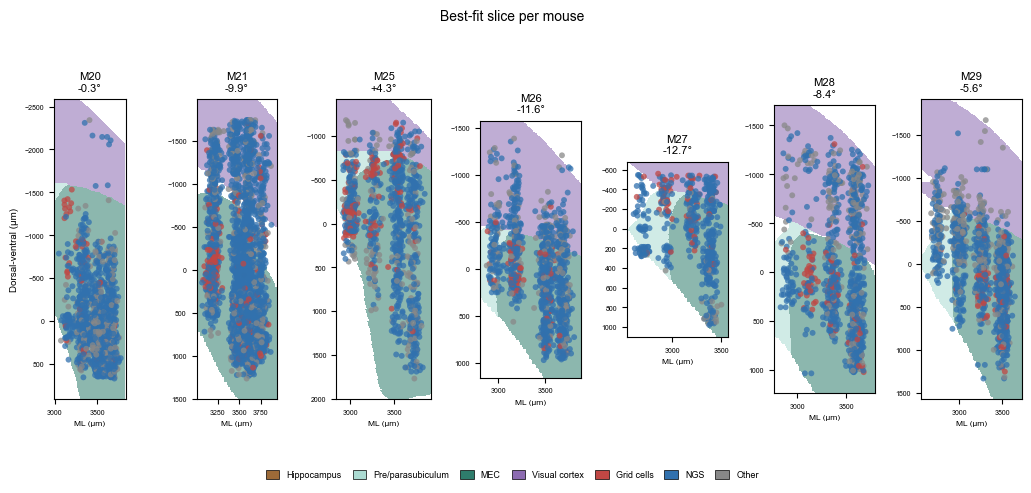

Saved → /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/mec_cells_permouse_slices.pdf
Cached 7 per-mouse best-fit slices → /Users/harryclark/Documents/spatial-manifolds/data/mec_best_fit_slices/M<mouse>_best_fit_slice.npz


In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import math
import re
from pathlib import Path
from tifffile import imread

plt.rcParams['font.family'] = 'Arial'

ML_JITTER_STD = 40.0  # see the previous cell — same jitter convention, applied per mouse here

# Cached so later scripts can project a given recording's cells onto the same
# best-fit plane / region background without redoing the plane fit or the
# (slow) annotation-volume sampling.
CACHE_DIR = Path('/Users/harryclark/Documents/spatial-manifolds/data/mec_best_fit_slices')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

annotations_set = imread('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/annotation.tiff')
structure_set = pd.read_csv('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/structures.csv')
id_to_acr = dict(zip(structure_set['id'], structure_set['acronym']))

def stereo_to_ccf(SC, angle=-0.0873):
    SC = np.asarray(SC, float)
    stretch = SC / np.array([1.0, 0.9434, 1.0])
    rotate = np.array([
        stretch[0]*math.cos(angle) - stretch[1]*math.sin(angle),
        stretch[0]*math.sin(angle) + stretch[1]*math.cos(angle),
        stretch[2]
    ])
    return rotate + np.array([5400.0, 440.0, 5700.0])

def _df_to_ccf(d):
    return np.array([stereo_to_ccf(r) for r in d[['SC_z', 'SC_y', 'SC_x']].values])

_df = load_classifications_v2()
_df = _df[_df['mouse'] != 22]
_df['SC_x'] = -np.abs(_df['SC_x'])

_jitter_rng = np.random.default_rng(1)

def _apply_ml_jitter(d):
    d = d.copy()
    if ML_JITTER_STD > 0:
        d['SC_x'] = d['SC_x'] + _jitter_rng.normal(0, ML_JITTER_STD, size=len(d))
    return d

# ── Brain region colour scheme (same as the previous cell) ──────────────────
COL_HIPPO   = '#9C6A38'
COL_PREPARA = '#ABDBD2'
COL_MEC     = '#2E7D6C'
COL_VIS     = '#8C6BB1'
REGION_LEGEND = [
    ('Hippocampus', COL_HIPPO),
    ('Pre/parasubiculum', COL_PREPARA),
    ('MEC', COL_MEC),
    ('Visual cortex', COL_VIS),
]

COL_GC    = '#c04744'
COL_NGS   = '#3171ae'
COL_OTHER = '#888888'
CELL_ALPHA = 0.75

_RE_HIPPO   = re.compile(r'^(CA[1-4]?|DG)(-|$)')
_RE_PREPARA = re.compile(r'^(PRE|PAR)\d*$')
_RE_MEC     = re.compile(r'^ENTm')
_RE_VIS     = re.compile(r'^VIS')

def _ids_to_numeric(aid_flat):
    numeric = np.zeros(len(aid_flat), dtype=int)
    for sid in np.unique(aid_flat):
        if sid == 0:
            continue
        acr = id_to_acr.get(sid, 'root')
        m = aid_flat == sid
        if _RE_HIPPO.match(acr):
            numeric[m] = 1
        elif _RE_PREPARA.match(acr):
            numeric[m] = 2
        elif _RE_MEC.match(acr):
            numeric[m] = 3
        elif _RE_VIS.match(acr):
            numeric[m] = 4
    return numeric

cmap_list = [(1, 1, 1, 0)]
for hexcol in [COL_HIPPO, COL_PREPARA, COL_MEC, COL_VIS]:
    r, g, b = tuple(int(hexcol.lstrip('#')[i:i+2], 16) / 255 for i in (0, 2, 4))
    cmap_list.append((r, g, b, 0.55))
region_cmap = ListedColormap(cmap_list)
region_norm = BoundaryNorm(np.arange(len(cmap_list) + 1) - 0.5, region_cmap.N)

def scatter_interleaved(ax, entries, rng):
    xs, ys, cs = [], [], []
    for x, y, color in entries:
        if len(x) == 0:
            continue
        xs.append(x); ys.append(y)
        cs.append(np.full(len(x), color))
    if not xs:
        return
    xs = np.concatenate(xs); ys = np.concatenate(ys); cs = np.concatenate(cs)
    order = rng.permutation(len(xs))
    ax.scatter(xs[order], ys[order], color=cs[order], s=18,
               alpha=CELL_ALPHA, zorder=3, edgecolor='none')

def fit_best_slice(fit_pts, extent_pts=None):
    """Same AP-DV-tilt-constrained best fit as the previous cell: ML axis stays
    exactly fixed in-plane, the plane tilts within AP×DV to best fit fit_pts
    (device contacts -- the physical probe geometry -- not cell locations,
    since per-cell ML positions are only a crude per-shank nominal + synthetic
    jitter approximation). extent_pts (defaults to fit_pts) sets the plotted
    u/v axis limits only -- pass the cell point cloud here so panels still
    frame the cells even though the fit itself no longer depends on them.

    basis1 (ML) never rotates, so u is reported as an *absolute* ML value
    (5700 - CCF_z, i.e. exactly the same 'ml = -SC_x' convention used
    everywhere else in this notebook) rather than centred on this particular
    mouse's own centroid — that keeps ML directly comparable across mice/
    panels. basis2 (the tilted AP-DV axis) has no such absolute equivalent —
    it's unique to each fit — so v stays relative to this fit's centroid."""
    if extent_pts is None:
        extent_pts = fit_pts
    plane_centroid = fit_pts.mean(axis=0)
    ay = fit_pts[:, [0, 1]]
    ay_c = ay - ay.mean(axis=0)
    _, _, Vt = np.linalg.svd(ay_c, full_matrices=False)
    major = Vt[0] if Vt[0][1] >= 0 else -Vt[0]
    minor = Vt[1] if Vt[1][0] >= 0 else -Vt[1]
    tilt_deg = np.degrees(np.arctan2(minor[1], minor[0]))

    normal = np.array([minor[0], minor[1], 0.0])
    basis1 = np.array([0.0, 0.0, 1.0])
    basis2 = np.array([major[0], major[1], 0.0])

    def project(pts):
        u = 5700.0 - pts[..., 2]                  # absolute ML (µm from the folded midline)
        v = (pts - plane_centroid) @ basis2        # AP-DV, relative to this fit's centroid
        return u, v

    def reconstruct(u, v):
        pts = np.empty(np.broadcast(np.asarray(u), np.asarray(v)).shape + (3,))
        pts[..., 0] = plane_centroid[0] + v * basis2[0]
        pts[..., 1] = plane_centroid[1] + v * basis2[1]
        pts[..., 2] = 5700.0 - u
        return pts

    u_ext, v_ext = project(extent_pts)
    pad_u = (u_ext.max() - u_ext.min()) * 0.08
    pad_v = (v_ext.max() - v_ext.min()) * 0.08
    u_lim = (u_ext.min() - pad_u, u_ext.max() + pad_u)
    v_lim = (v_ext.min() - pad_v, v_ext.max() + pad_v)

    u_fit, v_fit = project(fit_pts)
    proj = reconstruct(u_fit, v_fit)
    var_total = np.sum((fit_pts - plane_centroid) ** 2)
    var_resid = np.sum((fit_pts - proj) ** 2)
    var_explained = 1 - var_resid / var_total

    return dict(centroid=plane_centroid, basis1=basis1, basis2=basis2, normal=normal,
                u_lim=u_lim, v_lim=v_lim, tilt_deg=tilt_deg, var_explained=var_explained,
                project=project, reconstruct=reconstruct)

def sample_region_grid(fit, step=10):
    u_vals = np.arange(fit['u_lim'][0], fit['u_lim'][1], step)
    v_vals = np.arange(fit['v_lim'][0], fit['v_lim'][1], step)
    V, U = np.meshgrid(v_vals, u_vals, indexing='ij')
    grid_pts = fit['reconstruct'](U, V)
    idx0 = np.round(grid_pts[..., 0] / 10).astype(int)
    idx1 = np.round(grid_pts[..., 1] / 10).astype(int)
    idx2 = np.round(grid_pts[..., 2] / 10).astype(int)
    sh = annotations_set.shape
    valid = (idx0 >= 0) & (idx0 < sh[0]) & (idx1 >= 0) & (idx1 < sh[1]) & (idx2 >= 0) & (idx2 < sh[2])
    aid = np.zeros(idx0.shape, dtype=int)
    aid[valid] = annotations_set[idx0[valid], idx1[valid], idx2[valid]]
    region_grid = _ids_to_numeric(aid.ravel()).reshape(idx0.shape)
    return u_vals, v_vals, region_grid

MICE = sorted(int(m) for m in _df['mouse'].unique())

# Device contacts (all mice) -- the plane below is fit to these, not to cell
# locations (see fit_best_slice docstring above for why).
_dc_all = pd.read_csv('/Users/harryclark/Downloads/device_contact_id_annotations.csv')

def _dc_to_ccf(d):
    return np.array([stereo_to_ccf(r) for r in d[['coord_SCs_z', 'coord_SCs_y', 'coord_SCs_x']].values])

fig, axes = plt.subplots(1, len(MICE), figsize=(1.5 * len(MICE), 4.6))

for ax, mouse in zip(axes, MICE):
    dfm = _df[_df['mouse'] == mouse]
    gc    = _apply_ml_jitter(dfm[dfm['cell_type'] == 'GC'].dropna(subset=['SC_x', 'SC_y', 'SC_z']))
    ngs   = _apply_ml_jitter(dfm[dfm['cell_type'] == 'NG'].dropna(subset=['SC_x', 'SC_y', 'SC_z']))
    other = _apply_ml_jitter(dfm[~dfm['cell_type'].isin(['GC', 'NG'])].dropna(subset=['SC_x', 'SC_y', 'SC_z']))

    gc_pts    = _df_to_ccf(gc)    if len(gc) > 0    else np.empty((0, 3))
    ngs_pts   = _df_to_ccf(ngs)   if len(ngs) > 0   else np.empty((0, 3))
    other_pts = _df_to_ccf(other) if len(other) > 0 else np.empty((0, 3))
    all_pts   = np.concatenate([gc_pts, ngs_pts, other_pts], axis=0)

    print(f"M{mouse}: {len(gc)} grid cells, {len(ngs)} NGS, {len(other)} other")

    dc_m = _dc_all[_dc_all['mouse'] == mouse]
    contact_pts = _dc_to_ccf(dc_m)
    print(f"  {len(dc_m)} device contacts")

    fit = fit_best_slice(contact_pts, extent_pts=all_pts)
    u_vals, v_vals, region_grid = sample_region_grid(fit)
    print(f"  tilt from coronal: {fit['tilt_deg']:+.1f}°, variance explained: {fit['var_explained']*100:.1f}%")

    # Cache the plane definition + sampled region background for this mouse.
    # To project any (mouse, day, cluster) cell's CCF coords onto this same
    # plane later: u, v = (pts - centroid) @ basis1, (pts - centroid) @ basis2
    np.savez(
        CACHE_DIR / f'M{mouse}_best_fit_slice.npz',
        centroid=fit['centroid'], basis1=fit['basis1'], basis2=fit['basis2'], normal=fit['normal'],
        u_lim=np.array(fit['u_lim']), v_lim=np.array(fit['v_lim']),
        u_vals=u_vals, v_vals=v_vals, region_grid=region_grid,
        tilt_deg=fit['tilt_deg'], var_explained=fit['var_explained'],
    )

    u_gc, v_gc = fit['project'](gc_pts)
    u_ngs, v_ngs = fit['project'](ngs_pts)
    u_other, v_other = fit['project'](other_pts)

    _rng = np.random.default_rng(0)
    ax.pcolormesh(u_vals, v_vals, region_grid, cmap=region_cmap, norm=region_norm,
                  shading='nearest', rasterized=True, zorder=1)
    scatter_interleaved(ax, [
        (u_other, v_other, COL_OTHER),
        (u_ngs,   v_ngs,   COL_NGS),
        (u_gc,    v_gc,    COL_GC),
    ], _rng)
    ax.set_xlim(fit['u_lim'])  # ascending: u is already absolute ml, so this increases toward lateral
    ax.set_ylim(fit['v_lim'][1], fit['v_lim'][0])
    ax.set_aspect('equal')
    ax.set_title(f"M{mouse}\n{fit['tilt_deg']:+.1f}°", fontsize=8)
    ax.set_xlabel('ML (µm)', fontsize=6)
    ax.tick_params(labelsize=5)
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_linewidth(0.8)

axes[0].set_ylabel('Dorsal-ventral (µm)', fontsize=7)

cell_legend = [
    Patch(facecolor=COL_GC, edgecolor='black', lw=0.5, label='Grid cells'),
    Patch(facecolor=COL_NGS, edgecolor='black', lw=0.5, label='NGS'),
    Patch(facecolor=COL_OTHER, edgecolor='black', lw=0.5, label='Other'),
]
region_legend = [Patch(facecolor=c, edgecolor='black', lw=0.5, label=l) for l, c in REGION_LEGEND]
fig.legend(handles=region_legend + cell_legend, fontsize=6.5, frameon=False,
           loc='lower center', ncol=7, bbox_to_anchor=(0.5, -0.06),
           handlelength=1.5, handleheight=1.2, columnspacing=1.2)

fig.suptitle('Best-fit slice per mouse', fontsize=10)
fig.tight_layout(rect=[0, 0.04, 1, 0.94])

out_path = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/mec_cells_permouse_slices.pdf'
plt.savefig(out_path, bbox_inches='tight', dpi=1000)
plt.show()
print(f"Saved → {out_path}")
print(f"Cached {len(MICE)} per-mouse best-fit slices → {CACHE_DIR}/M<mouse>_best_fit_slice.npz")


In [ ]:
from brainrender import Scene, settings as br_settings
from brainrender.actors import Points
from brainrender.actor import Actor
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import math
from pathlib import Path
from vedo import Mesh as VedoMesh
from tifffile import imread

br_settings.SHOW_AXES        = False
br_settings.BACKGROUND_COLOR = [1, 1, 1]

SAVE_DIR = Path('/tmp/mec_renders')
SAVE_DIR.mkdir(exist_ok=True)
MOUSE = 26

annotations_set = imread('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/annotation.tiff')
structure_set = pd.read_csv('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/structures.csv')
id_to_acr = dict(zip(structure_set['id'], structure_set['acronym']))

def stereo_to_ccf(SC, angle=-0.0873):
    SC = np.asarray(SC, float)
    stretch = SC / np.array([1.0, 0.9434, 1.0])
    rotate = np.array([
        stretch[0]*math.cos(angle) - stretch[1]*math.sin(angle),
        stretch[0]*math.sin(angle) + stretch[1]*math.cos(angle),
        stretch[2]
    ])
    return rotate + np.array([5400.0, 440.0, 5700.0])

# ── M26 cells (context only -- the plane below is fit to device contacts,
# not to these; see the per-mouse best-fit cell above for why) ──────────────
_df = load_classifications_v2()
_df = _df[_df['mouse'] == MOUSE]
_df['SC_x'] = -np.abs(_df['SC_x'])

_gc    = _df[_df['cell_type'] == 'GC'].dropna(subset=['SC_x', 'SC_y', 'SC_z'])
_ngs   = _df[_df['cell_type'] == 'NG'].dropna(subset=['SC_x', 'SC_y', 'SC_z'])
_other = _df[~_df['cell_type'].isin(['GC', 'NG'])].dropna(subset=['SC_x', 'SC_y', 'SC_z'])

def _df_to_ccf(d):
    return np.array([stereo_to_ccf(r) for r in d[['SC_z', 'SC_y', 'SC_x']].values])

gc_pts    = _df_to_ccf(_gc)    if len(_gc) > 0    else np.empty((0, 3))
ngs_pts   = _df_to_ccf(_ngs)   if len(_ngs) > 0   else np.empty((0, 3))
other_pts = _df_to_ccf(_other) if len(_other) > 0 else np.empty((0, 3))
all_pts   = np.concatenate([gc_pts, ngs_pts, other_pts], axis=0)

# ── M26 device contacts -- the plane is fit to these ────────────────────────
_dc = pd.read_csv('/Users/harryclark/Downloads/device_contact_id_annotations.csv')
_dc = _dc[_dc['mouse'] == MOUSE]

def _dc_to_ccf(d):
    return np.array([stereo_to_ccf(r) for r in d[['coord_SCs_z', 'coord_SCs_y', 'coord_SCs_x']].values])

contact_pts = _dc_to_ccf(_dc)
print(f"M{MOUSE}: {len(_gc)} grid cells, {len(_ngs)} NGS, {len(_other)} other, {len(_dc)} device contacts")

# ── Best-fit plane through M26's device contacts (same AP-DV-tilt-constrained
# fit as the per-mouse best-fit cell above: ML axis stays exactly fixed
# in-plane, only the AP-DV tilt is free) ─────────────────────────────────────
plane_centroid = contact_pts.mean(axis=0)
_ay = contact_pts[:, [0, 1]]
_ay_c = _ay - _ay.mean(axis=0)
_, _, _Vt = np.linalg.svd(_ay_c, full_matrices=False)
_major = _Vt[0] if _Vt[0][1] >= 0 else -_Vt[0]
_minor = _Vt[1] if _Vt[1][0] >= 0 else -_Vt[1]
tilt_from_coronal_deg = np.degrees(np.arctan2(_minor[1], _minor[0]))

normal = np.array([_minor[0], _minor[1], 0.0])
basis1 = np.array([0.0, 0.0, 1.0])
basis2 = np.array([_major[0], _major[1], 0.0])

def project_to_plane(pts):
    rel = pts - plane_centroid
    return rel @ basis1, rel @ basis2

# Axis/plane EXTENT comes from the cells (what's shown), even though the fit
# itself comes from contacts.
u_all, v_all = project_to_plane(all_pts)
_pad_u = (u_all.max() - u_all.min()) * 0.15
_pad_v = (v_all.max() - v_all.min()) * 0.15
u_lim = (u_all.min() - _pad_u, u_all.max() + _pad_u)
v_lim = (v_all.min() - _pad_v, v_all.max() + _pad_v)

u_contact, v_contact = project_to_plane(contact_pts)
_proj_contact = plane_centroid + np.outer(u_contact, basis1) + np.outer(v_contact, basis2)
var_explained = 1 - np.sum((contact_pts - _proj_contact) ** 2) / np.sum((contact_pts - plane_centroid) ** 2)

print(f"Best-fit plane (M{MOUSE}, fit to device contacts): {tilt_from_coronal_deg:+.1f}° from pure coronal, "
      f"centroid: ({plane_centroid[0]:.0f}, {plane_centroid[1]:.0f}, {plane_centroid[2]:.0f}) µm, "
      f"variance explained: {var_explained*100:.1f}%")

# ── Brain region colours (same scheme as the other brainrender cells) ───────
COL_HIPPO   = '#9C6A38'
COL_PREPARA = '#ABDBD2'
COL_MEC     = '#2E7D6C'
STRUCT_REGIONS = [
    ('CA',   COL_HIPPO,   0.40),
    ('DG',   COL_HIPPO,   0.40),
    ('PRE',  COL_PREPARA, 0.18),
    ('PAR',  COL_PREPARA, 0.18),
    ('ENTm', COL_MEC,     0.18),
]
REGION_LEGEND = [
    ('Hippocampus', COL_HIPPO),
    ('Pre/parasubiculum', COL_PREPARA),
    ('MEC', COL_MEC),
]

COL_GC      = '#c04744'
COL_NGS     = '#3171ae'
COL_OTHER   = '#888888'
COL_CONTACT = '#ff6500'

CELL_RADIUS = 35
CONTACT_RADIUS = 40
CELL_ALPHA = 0.75

_rng = np.random.default_rng(0)

def interleaved_cloud(other_p, ngs_p, gc_p, rng):
    coords, colors = [], []
    for arr, col in [(other_p, COL_OTHER), (ngs_p, COL_NGS), (gc_p, COL_GC)]:
        if len(arr) == 0:
            continue
        coords.append(arr)
        colors.extend([col] * len(arr))
    if not coords:
        return np.empty((0, 3)), []
    coords = np.concatenate(coords)
    colors = np.array(colors)
    order = rng.permutation(len(coords))
    return coords[order], list(colors[order])

def add_regions(scene):
    for rname, color, alpha in STRUCT_REGIONS:
        try:
            scene.add_brain_region(rname, alpha=alpha, color=color)
        except Exception as e:
            print(f'  skipped {rname}: {e}')

def make_plane_actors():
    corners = np.array([
        plane_centroid + u_lim[0]*basis1 + v_lim[0]*basis2,
        plane_centroid + u_lim[1]*basis1 + v_lim[0]*basis2,
        plane_centroid + u_lim[1]*basis1 + v_lim[1]*basis2,
        plane_centroid + u_lim[0]*basis1 + v_lim[1]*basis2,
    ])
    faces = [[0, 1, 2], [0, 2, 3]]
    fill = VedoMesh([corners, faces]).c('black').alpha(0.12)
    edge = VedoMesh([corners, faces]).wireframe().c('black').lw(3).alpha(1.0)
    return fill, edge

def build_m26_scene():
    scene = Scene(root=True, atlas_name='allen_mouse_10um', title='')
    add_regions(scene)
    plane_fill, plane_edge = make_plane_actors()
    scene.add(Actor(plane_fill, name='slice_fill', br_class='mesh'))
    scene.add(Actor(plane_edge, name='slice_edge', br_class='mesh'))
    scene.add(Points(contact_pts, name='contacts', colors=COL_CONTACT, radius=CONTACT_RADIUS, alpha=0.6))
    coords, colors = interleaved_cloud(other_pts, ngs_pts, gc_pts, _rng)
    if len(coords):
        scene.add(Points(coords, name='cells', colors=colors, radius=CELL_RADIUS, alpha=CELL_ALPHA))
    return scene

FOCAL = (float(plane_centroid[0]), float(plane_centroid[1]), float(-plane_centroid[2]))
R_horiz, DV_ELEV = 35000, -15000
rad_320 = np.radians(320)
cam_full = {
    'pos':            (FOCAL[0] + R_horiz * np.cos(rad_320),
                       FOCAL[1] + DV_ELEV,
                       FOCAL[2] - R_horiz * np.sin(rad_320)),
    'focal_point':    FOCAL,
    'viewup':         (0, -1, 0),
    'clipping_range': (20000, 60000),
}

print(f"Rendering M{MOUSE} best-fit slice (device-contact plane, contacts + cells)…")
scene = build_m26_scene()
scene.render(camera=cam_full, interactive=False, zoom=2)
scene.screenshot(name=str(SAVE_DIR / f'm{MOUSE}_slice_plane'), scale=2)
try:
    scene.close()
except Exception:
    pass
img_full = mpimg.imread(str(SAVE_DIR / f'm{MOUSE}_slice_plane.png'))



# ── Figure: full oblique view + clipped close-up, side by side ──────────────
fig, ax = plt.subplots(1, 1, figsize=(6, 5.2))
ax.imshow(img_full); ax.axis('off')
ax.set_title(f'M{MOUSE}: full brain, best-fit slice plane', fontsize=9)

legend_handles = (
    [Patch(facecolor=c, edgecolor='black', lw=0.5, label=l) for l, c in REGION_LEGEND]
    + [Patch(facecolor=COL_CONTACT, edgecolor='black', lw=0.5, label='Device contacts')]
    + [Patch(facecolor=COL_GC, edgecolor='black', lw=0.5, label='Grid cells'),
       Patch(facecolor=COL_NGS, edgecolor='black', lw=0.5, label='NGS'),
       Patch(facecolor=COL_OTHER, edgecolor='black', lw=0.5, label='Other')]
)
fig.legend(handles=legend_handles, fontsize=7, frameon=False, loc='lower center',
           ncol=7, bbox_to_anchor=(0.5, -0.02), handlelength=1.5, handleheight=1.2)

fig.suptitle(f'M{MOUSE} best-fit slice, fit to device contacts '
             f'({tilt_from_coronal_deg:+.1f}° from coronal, {var_explained*100:.1f}% variance explained)',
             fontsize=10)
fig.tight_layout(rect=[0, 0.04, 1, 0.95])

out_path = f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/m{MOUSE}_best_fit_slice_brainrender.pdf'
plt.savefig(out_path, bbox_inches='tight', dpi=600)
plt.show()
print(f"Saved → {out_path}")


D24: 10 GC + 14 NGS = 24
D19: 6 GC + 18 NGS = 24
D22: 3 GC + 21 NGS = 24
D23: 1 GC + 23 NGS = 24
M25: tilt +4.3°, variance explained 100.0%
All mice: tilt -4.1°, variance explained 96.3%


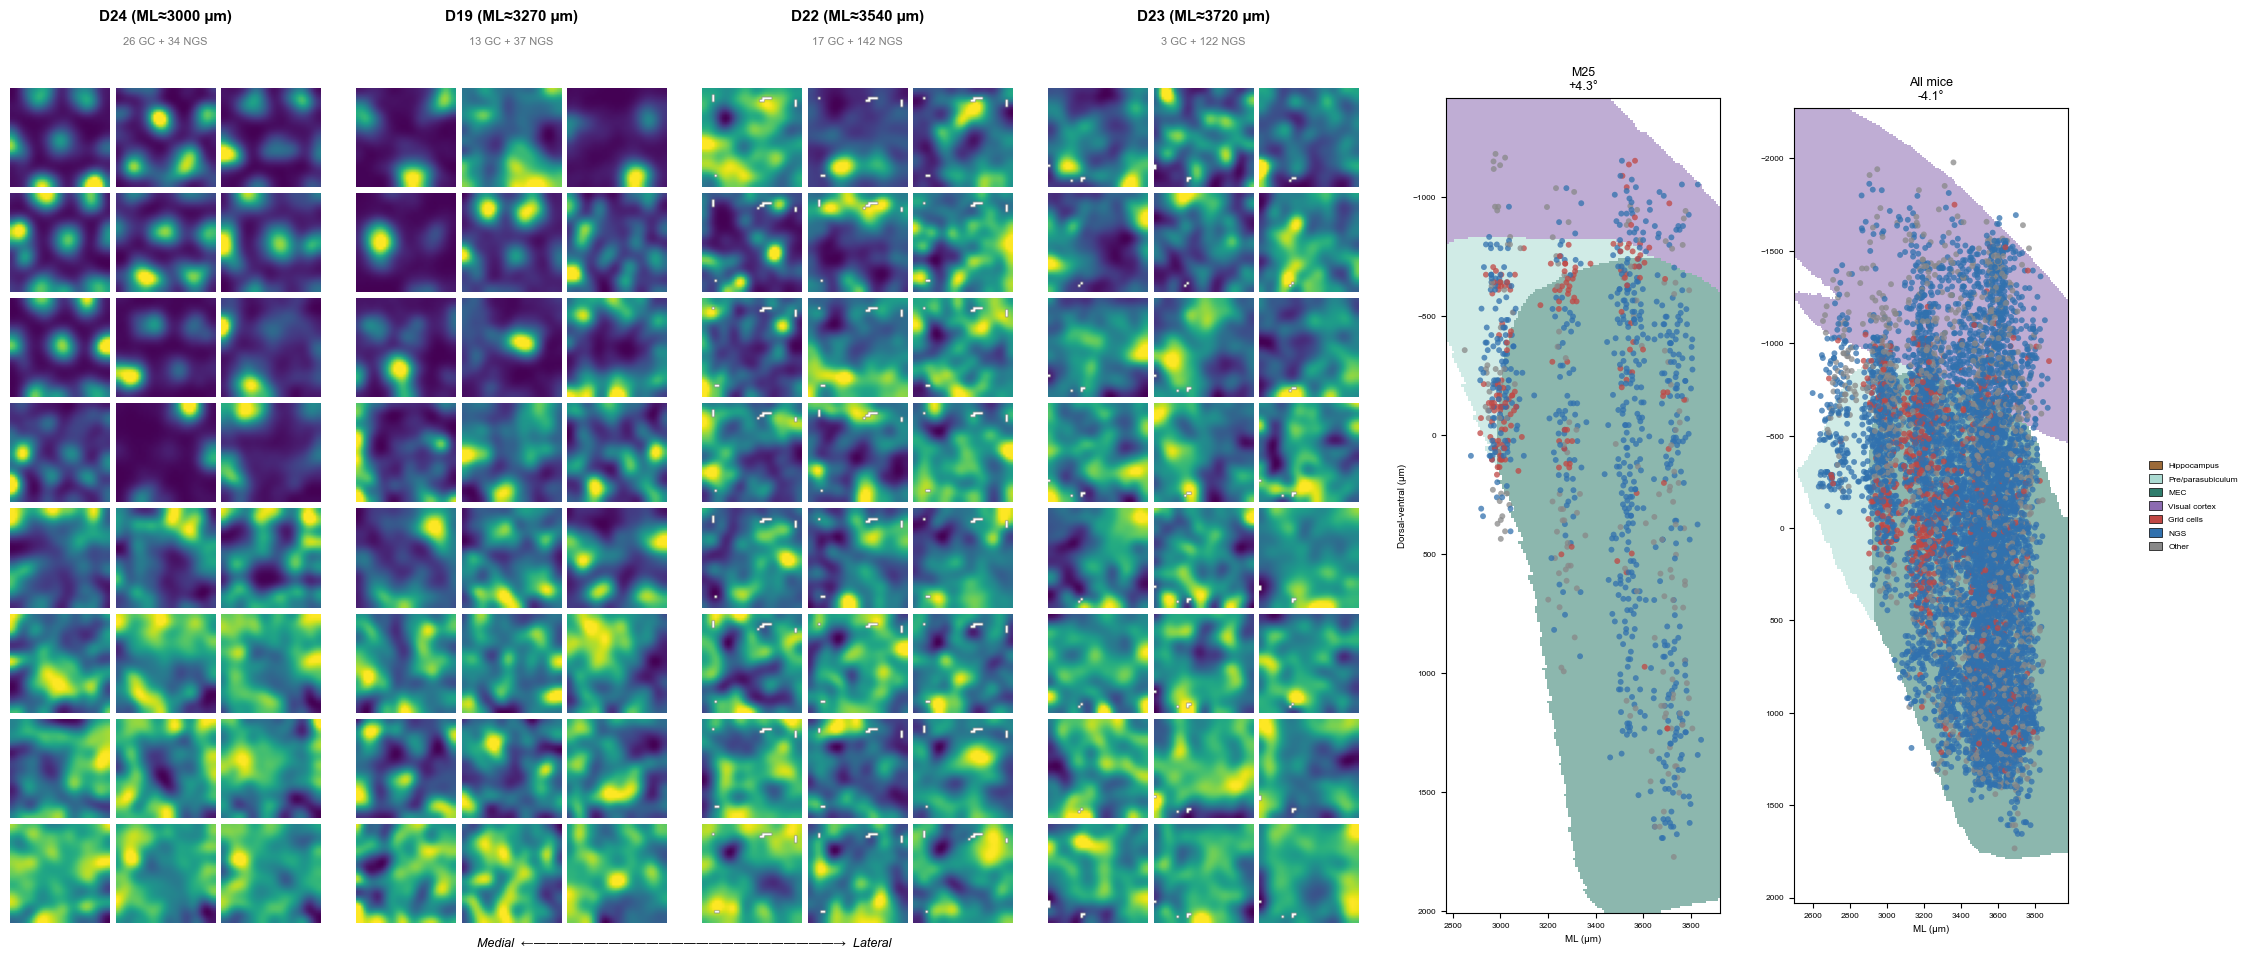

Saved → /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/best_fit_slices_with_M25_ratemaps.pdf


In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import math
import re
import pynapple as nap
from tifffile import imread
from spatial_manifolds.detect_grids import (
    compute_travel_projected, gaussian_filter_nan, _fill_nans_from_neighbors,
)

plt.rcParams['font.family'] = 'Arial'

# ══════════════════════════════════════════════════════════════════════════════
# Panel 1 setup: best-fit slices (same fitting logic as the per-mouse cell above)
# ══════════════════════════════════════════════════════════════════════════════

ML_JITTER_STD = 40.0

annotations_set = imread('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/annotation.tiff')
structure_set = pd.read_csv('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/structures.csv')
id_to_acr = dict(zip(structure_set['id'], structure_set['acronym']))

def stereo_to_ccf(SC, angle=-0.0873):
    SC = np.asarray(SC, float)
    stretch = SC / np.array([1.0, 0.9434, 1.0])
    rotate = np.array([
        stretch[0]*math.cos(angle) - stretch[1]*math.sin(angle),
        stretch[0]*math.sin(angle) + stretch[1]*math.cos(angle),
        stretch[2]
    ])
    return rotate + np.array([5400.0, 440.0, 5700.0])

def _df_to_ccf(d):
    return np.array([stereo_to_ccf(r) for r in d[['SC_z', 'SC_y', 'SC_x']].values])

_df_regions = load_classifications_v2()
_df_regions = _df_regions[_df_regions['mouse'] != 22]
_df_regions['SC_x'] = -np.abs(_df_regions['SC_x'])

_jitter_rng = np.random.default_rng(1)

def _apply_ml_jitter(d):
    d = d.copy()
    if ML_JITTER_STD > 0:
        d['SC_x'] = d['SC_x'] + _jitter_rng.normal(0, ML_JITTER_STD, size=len(d))
    return d

COL_HIPPO   = '#9C6A38'
COL_PREPARA = '#ABDBD2'
COL_MEC     = '#2E7D6C'
COL_VIS     = '#8C6BB1'
REGION_LEGEND = [
    ('Hippocampus', COL_HIPPO),
    ('Pre/parasubiculum', COL_PREPARA),
    ('MEC', COL_MEC),
    ('Visual cortex', COL_VIS),
]

COL_GC    = '#c04744'
COL_NGS   = '#3171ae'
COL_OTHER = '#888888'
CELL_ALPHA = 0.75

_RE_HIPPO   = re.compile(r'^(CA[1-4]?|DG)(-|$)')
_RE_PREPARA = re.compile(r'^(PRE|PAR)\d*$')
_RE_MEC     = re.compile(r'^ENTm')
_RE_VIS     = re.compile(r'^VIS')

def _ids_to_numeric(aid_flat):
    numeric = np.zeros(len(aid_flat), dtype=int)
    for sid in np.unique(aid_flat):
        if sid == 0:
            continue
        acr = id_to_acr.get(sid, 'root')
        m = aid_flat == sid
        if _RE_HIPPO.match(acr):
            numeric[m] = 1
        elif _RE_PREPARA.match(acr):
            numeric[m] = 2
        elif _RE_MEC.match(acr):
            numeric[m] = 3
        elif _RE_VIS.match(acr):
            numeric[m] = 4
    return numeric

cmap_list = [(1, 1, 1, 0)]
for hexcol in [COL_HIPPO, COL_PREPARA, COL_MEC, COL_VIS]:
    r, g, b = tuple(int(hexcol.lstrip('#')[i:i+2], 16) / 255 for i in (0, 2, 4))
    cmap_list.append((r, g, b, 0.55))
region_cmap = ListedColormap(cmap_list)
region_norm = BoundaryNorm(np.arange(len(cmap_list) + 1) - 0.5, region_cmap.N)

def scatter_interleaved(ax, entries, rng):
    xs, ys, cs = [], [], []
    for x, y, color in entries:
        if len(x) == 0:
            continue
        xs.append(x); ys.append(y)
        cs.append(np.full(len(x), color))
    if not xs:
        return
    xs = np.concatenate(xs); ys = np.concatenate(ys); cs = np.concatenate(cs)
    order = rng.permutation(len(xs))
    ax.scatter(xs[order], ys[order], color=cs[order], s=18,
               alpha=CELL_ALPHA, zorder=3, edgecolor='none')

def fit_best_slice(fit_pts, extent_pts=None):
    """AP-DV-tilt-constrained best fit: ML axis stays exactly fixed in-plane
    (reported as an absolute value — 5700 - CCF_z, i.e. the same 'ml = -SC_x'
    convention used elsewhere), the plane tilts within AP×DV to best fit
    fit_pts (device contacts -- the physical probe geometry -- not cell
    locations, since per-cell ML positions are only a crude per-shank nominal
    + synthetic jitter approximation). extent_pts (defaults to fit_pts) sets
    the plotted u/v axis limits only -- pass the cell point cloud here so the
    panel still frames the cells even though the fit itself no longer depends
    on them. v stays relative to this fit's own centroid, since that tilted
    axis has no absolute equivalent."""
    if extent_pts is None:
        extent_pts = fit_pts
    plane_centroid = fit_pts.mean(axis=0)
    ay = fit_pts[:, [0, 1]]
    ay_c = ay - ay.mean(axis=0)
    _, _, Vt = np.linalg.svd(ay_c, full_matrices=False)
    major = Vt[0] if Vt[0][1] >= 0 else -Vt[0]
    minor = Vt[1] if Vt[1][0] >= 0 else -Vt[1]
    tilt_deg = np.degrees(np.arctan2(minor[1], minor[0]))

    normal = np.array([minor[0], minor[1], 0.0])
    basis1 = np.array([0.0, 0.0, 1.0])
    basis2 = np.array([major[0], major[1], 0.0])

    def project(pts):
        u = 5700.0 - pts[..., 2]
        v = (pts - plane_centroid) @ basis2
        return u, v

    def reconstruct(u, v):
        pts = np.empty(np.broadcast(np.asarray(u), np.asarray(v)).shape + (3,))
        pts[..., 0] = plane_centroid[0] + v * basis2[0]
        pts[..., 1] = plane_centroid[1] + v * basis2[1]
        pts[..., 2] = 5700.0 - u
        return pts

    u_ext, v_ext = project(extent_pts)
    pad_u = (u_ext.max() - u_ext.min()) * 0.08
    pad_v = (v_ext.max() - v_ext.min()) * 0.08
    u_lim = (u_ext.min() - pad_u, u_ext.max() + pad_u)
    v_lim = (v_ext.min() - pad_v, v_ext.max() + pad_v)

    u_fit, v_fit = project(fit_pts)
    proj = reconstruct(u_fit, v_fit)
    var_total = np.sum((fit_pts - plane_centroid) ** 2)
    var_resid = np.sum((fit_pts - proj) ** 2)
    var_explained = 1 - var_resid / var_total

    return dict(centroid=plane_centroid, basis1=basis1, basis2=basis2, normal=normal,
                u_lim=u_lim, v_lim=v_lim, tilt_deg=tilt_deg, var_explained=var_explained,
                project=project, reconstruct=reconstruct)

def sample_region_grid(fit, step=10):
    u_vals = np.arange(fit['u_lim'][0], fit['u_lim'][1], step)
    v_vals = np.arange(fit['v_lim'][0], fit['v_lim'][1], step)
    V, U = np.meshgrid(v_vals, u_vals, indexing='ij')
    grid_pts = fit['reconstruct'](U, V)
    idx0 = np.round(grid_pts[..., 0] / 10).astype(int)
    idx1 = np.round(grid_pts[..., 1] / 10).astype(int)
    idx2 = np.round(grid_pts[..., 2] / 10).astype(int)
    sh = annotations_set.shape
    valid = (idx0 >= 0) & (idx0 < sh[0]) & (idx1 >= 0) & (idx1 < sh[1]) & (idx2 >= 0) & (idx2 < sh[2])
    aid = np.zeros(idx0.shape, dtype=int)
    aid[valid] = annotations_set[idx0[valid], idx1[valid], idx2[valid]]
    region_grid = _ids_to_numeric(aid.ravel()).reshape(idx0.shape)
    return u_vals, v_vals, region_grid

def get_mouse_pts(mouse=None):
    """mouse=None pools cells across all mice."""
    d = _df_regions if mouse is None else _df_regions[_df_regions['mouse'] == mouse]
    gc    = _apply_ml_jitter(d[d['cell_type'] == 'GC'].dropna(subset=['SC_x', 'SC_y', 'SC_z']))
    ngs   = _apply_ml_jitter(d[d['cell_type'] == 'NG'].dropna(subset=['SC_x', 'SC_y', 'SC_z']))
    other = _apply_ml_jitter(d[~d['cell_type'].isin(['GC', 'NG'])].dropna(subset=['SC_x', 'SC_y', 'SC_z']))
    gc_pts    = _df_to_ccf(gc)    if len(gc) > 0    else np.empty((0, 3))
    ngs_pts   = _df_to_ccf(ngs)   if len(ngs) > 0   else np.empty((0, 3))
    other_pts = _df_to_ccf(other) if len(other) > 0 else np.empty((0, 3))
    return gc_pts, ngs_pts, other_pts

_dc_all = pd.read_csv('/Users/harryclark/Downloads/device_contact_id_annotations.csv')
_dc_all = _dc_all[_dc_all['mouse'] != 22]

def _dc_to_ccf(d):
    return np.array([stereo_to_ccf(r) for r in d[['coord_SCs_z', 'coord_SCs_y', 'coord_SCs_x']].values])

def get_mouse_contacts(mouse=None):
    """mouse=None pools device contacts across all mice. The plane is fit to
    these, not to cell locations -- see fit_best_slice docstring above."""
    d = _dc_all if mouse is None else _dc_all[_dc_all['mouse'] == mouse]
    return _dc_to_ccf(d)

SLICE_PANELS = [('M25', 25), ('All mice', None)]

# ══════════════════════════════════════════════════════════════════════════════
# Panel 2 setup: M25 proportional GC/NGS rate maps, 4 sessions — identical
# selection + plotting logic to the existing M25 example-cell figure cell.
# ══════════════════════════════════════════════════════════════════════════════

SOURCE_PATH = '/Users/harryclark/Downloads/clark2025/'

def _load_beh_clusters(mouse, day, session, source_path=SOURCE_PATH):
    folder = f'{source_path}M{int(mouse)}/D{int(day):02}/{session}/'
    spikes_path = folder + f"sub-{int(mouse)}_day-{int(day):02}_ses-{session}_srt-kilosort4_clusters.npz"
    beh_path = folder + f"sub-{int(mouse)}_day-{int(day):02}_ses-{session}_beh.nwb"
    beh = nap.load_file(beh_path)
    clusters = nap.load_file(spikes_path)
    return beh, clusters

def plot_of_rate_map(ax, cluster_id, mouse, day, df, session='OF1', source_path=SOURCE_PATH):
    beh, clusters = _load_beh_clusters(mouse, day, session, source_path)
    optimal_lag = df[df.cluster_id == cluster_id].travel.values[0]
    position = np.stack([beh['P_x'], beh['P_y']], axis=1)
    beh_lag = compute_travel_projected(["P_x", "P_y"], position, position, optimal_lag)
    position_lagged = np.stack([beh_lag['P_x'], beh_lag['P_y']], axis=1)
    tc = nap.compute_2d_tuning_curves(nap.TsGroup([clusters[cluster_id]]), position_lagged, nb_bins=(40, 40))[0][0]
    tc = _fill_nans_from_neighbors(tc)
    tc = gaussian_filter_nan(tc, sigma=(2.5, 2.5))
    tc = np.clip(tc, a_min=0, a_max=np.nanpercentile(tc, 99))
    ax.imshow(tc, cmap='viridis')
    ax.axis('off')

_df_class = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')

mouse = 25
sessions = [24, 19, 22, 23]
N_TOTAL = 24
N_COLS_PER_SESSION = 3
N_ROWS = N_TOTAL // N_COLS_PER_SESSION

np.random.seed(42)

session_cells = {}
session_counts = {}

for day in sessions:
    sub = _df_class[(_df_class['mouse'] == mouse) & (_df_class['day'] == day)]
    gc = sub[sub['cell_type'] == 'GC'].copy()
    gc['ml'] = gc['SC_x'].abs()
    ngs = sub[sub['cell_type'] == 'NG'].copy()
    ngs['ml'] = ngs['SC_x'].abs()
    other = sub[sub['cell_type'] == 'Other']

    session_counts[day] = {
        'GC_both': len(gc[gc['classified_by'] == 'both']),
        'GC_either': len(gc[gc['classified_by'].isin(['OF1', 'OF2'])]),
        'NGS': len(ngs),
        'Other': len(other),
        'Total': len(sub),
    }

    total = len(gc) + len(ngs)
    n_gc = round((len(gc) / total) * N_TOTAL) if total > 0 else 0
    n_gc = max(n_gc, min(1, len(gc)))
    n_ngs = N_TOTAL - n_gc

    gc = gc.sort_values('grid_score_best', ascending=False)
    if len(gc) > n_gc:
        gc = gc.head(n_gc)

    ngs_sorted_dv = ngs.sort_values('SC_y')
    if len(ngs_sorted_dv) > n_ngs:
        idx = np.linspace(0, len(ngs_sorted_dv) - 1, n_ngs).astype(int)
        ngs = ngs_sorted_dv.iloc[idx]
    else:
        ngs = ngs_sorted_dv
    ngs = ngs.sort_values('spatial_information_score_best', ascending=False)

    gc = gc.copy()
    ngs = ngs.copy()
    gc['_type'] = 'GC'
    ngs['_type'] = 'NGS'
    combined = pd.concat([gc, ngs]).reset_index(drop=True)
    session_cells[day] = combined
    print(f'D{day}: {len(gc)} GC + {len(ngs)} NGS = {len(combined)}')

# ══════════════════════════════════════════════════════════════════════════════
# Combined figure: left = 4-session rate-map grid, right = 3 best-fit slice columns
# (each slice column sized to match one session block: N_COLS_PER_SESSION wide)
# ══════════════════════════════════════════════════════════════════════════════

n_slice_cols = len(SLICE_PANELS)
total_ratemap_cols = len(sessions) * N_COLS_PER_SESSION

session_width = N_COLS_PER_SESSION * 1.2   # one session block's width, in inches
ratemap_width = total_ratemap_cols * 1.2
legend_width = 1.1
slice_width = n_slice_cols * session_width  # each slice column == one session's width
fig_h = N_ROWS * 1.2

fig = plt.figure(figsize=(ratemap_width + 0.4 + slice_width + legend_width, fig_h))
outer = gridspec.GridSpec(1, 2, figure=fig, wspace=0.08,
                          width_ratios=[ratemap_width, slice_width + legend_width],
                          top=0.90, bottom=0.03, left=0.02, right=0.98)

# ── Right panel: best-fit slices (+ a dedicated column for their shared legend) ──
slice_gs = outer[0, 1].subgridspec(1, n_slice_cols + 1, wspace=0.35,
                                   width_ratios=[1] * n_slice_cols + [legend_width / session_width])
slice_axes = []
for col_idx, (label, mouse_id) in enumerate(SLICE_PANELS):
    ax = fig.add_subplot(slice_gs[0, col_idx])
    slice_axes.append(ax)

    gc_pts, ngs_pts, other_pts = get_mouse_pts(mouse_id)
    all_pts = np.concatenate([gc_pts, ngs_pts, other_pts], axis=0)
    contact_pts = get_mouse_contacts(mouse_id)
    fit = fit_best_slice(contact_pts, extent_pts=all_pts)
    u_vals, v_vals, region_grid = sample_region_grid(fit)
    print(f"{label}: tilt {fit['tilt_deg']:+.1f}°, variance explained {fit['var_explained']*100:.1f}%")

    u_gc, v_gc = fit['project'](gc_pts)
    u_ngs, v_ngs = fit['project'](ngs_pts)
    u_other, v_other = fit['project'](other_pts)

    _rng = np.random.default_rng(0)
    ax.pcolormesh(u_vals, v_vals, region_grid, cmap=region_cmap, norm=region_norm,
                  shading='nearest', rasterized=True, zorder=1)
    scatter_interleaved(ax, [
        (u_other, v_other, COL_OTHER),
        (u_ngs,   v_ngs,   COL_NGS),
        (u_gc,    v_gc,    COL_GC),
    ], _rng)
    ax.set_xlim(fit['u_lim'])
    ax.set_ylim(fit['v_lim'][1], fit['v_lim'][0])
    ax.set_aspect('equal')
    ax.set_title(f"{label}\n{fit['tilt_deg']:+.1f}°", fontsize=9)
    ax.set_xlabel('ML (µm)', fontsize=7)
    ax.tick_params(labelsize=6)
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_linewidth(0.8)

slice_axes[0].set_ylabel('Dorsal-ventral (µm)', fontsize=7)

cell_legend = [
    Patch(facecolor=COL_GC, edgecolor='black', lw=0.5, label='Grid cells'),
    Patch(facecolor=COL_NGS, edgecolor='black', lw=0.5, label='NGS'),
    Patch(facecolor=COL_OTHER, edgecolor='black', lw=0.5, label='Other'),
]
region_legend = [Patch(facecolor=c, edgecolor='black', lw=0.5, label=l) for l, c in REGION_LEGEND]
ax_legend = fig.add_subplot(slice_gs[0, n_slice_cols])
ax_legend.axis('off')
ax_legend.legend(handles=region_legend + cell_legend, fontsize=6, frameon=False,
                  loc='center left', handlelength=1.5, handleheight=1.2, labelspacing=0.6)

# ── Left panel: M25 rate maps, 4 sessions ────────────────────────────────────
ratemap_gs = outer[0, 0].subgridspec(1, len(sessions), wspace=0.1)

for s_idx, day in enumerate(sessions):
    cells = session_cells[day]
    ml_val = cells['ml'].iloc[0] if len(cells) > 0 else 0
    counts = session_counts[day]

    inner = ratemap_gs[0, s_idx].subgridspec(N_ROWS, N_COLS_PER_SESSION, wspace=0.02, hspace=0.06)

    mid_x = (ratemap_gs[0, s_idx].get_position(fig).x0 + ratemap_gs[0, s_idx].get_position(fig).x1) / 2
    fig.text(mid_x, 0.97, f'D{day} (ML≈{ml_val:.0f} µm)',
             ha='center', fontsize=11, weight='bold')
    fig.text(mid_x, 0.945, f'{counts["GC_both"]+counts["GC_either"]} GC + {counts["NGS"]} NGS',
             ha='center', fontsize=8, color='grey')

    for idx in range(min(len(cells), N_TOTAL)):
        r = idx // N_COLS_PER_SESSION
        c = idx % N_COLS_PER_SESSION
        ax = fig.add_subplot(inner[r, c])

        ex = cells.iloc[idx]
        cid = int(ex.cluster_id)

        try:
            plot_of_rate_map(ax, cid, mouse, day, _df_class, session='OF1')
        except Exception as e:
            ax.text(0.5, 0.5, '—', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='grey')
            ax.axis('off')
            print(f"  Failed M{mouse}D{day} c{cid}: {e}")

    for idx in range(len(cells), N_ROWS * N_COLS_PER_SESSION):
        r = idx // N_COLS_PER_SESSION
        c = idx % N_COLS_PER_SESSION
        ax = fig.add_subplot(inner[r, c])
        ax.axis('off')

ratemap_x0 = outer[0, 0].get_position(fig).x0
ratemap_x1 = outer[0, 0].get_position(fig).x1
fig.text((ratemap_x0 + ratemap_x1) / 2, 0.005,
         'Medial  ←――――――――――――――――――――――――→  Lateral',
         ha='center', fontsize=9, style='italic')

out_path = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/best_fit_slices_with_M25_ratemaps.pdf'
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved → {out_path}")


MEC cells: 6900
  Grid cells: 616
  NGS: 5177
  Other: 1107


  Grid cells Spatial information
(bits/spike): fit (n=616)


  Grid cells Firing rate (Hz): fit (n=616)


/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


  Grid cells Spatial sparsity: fit (n=616)


...

/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


  Other Spatial information
(bits/spike): fit (n=1107)


  Other Firing rate (Hz): fit (n=1107)


/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


  Other Spatial sparsity: fit (n=1107)


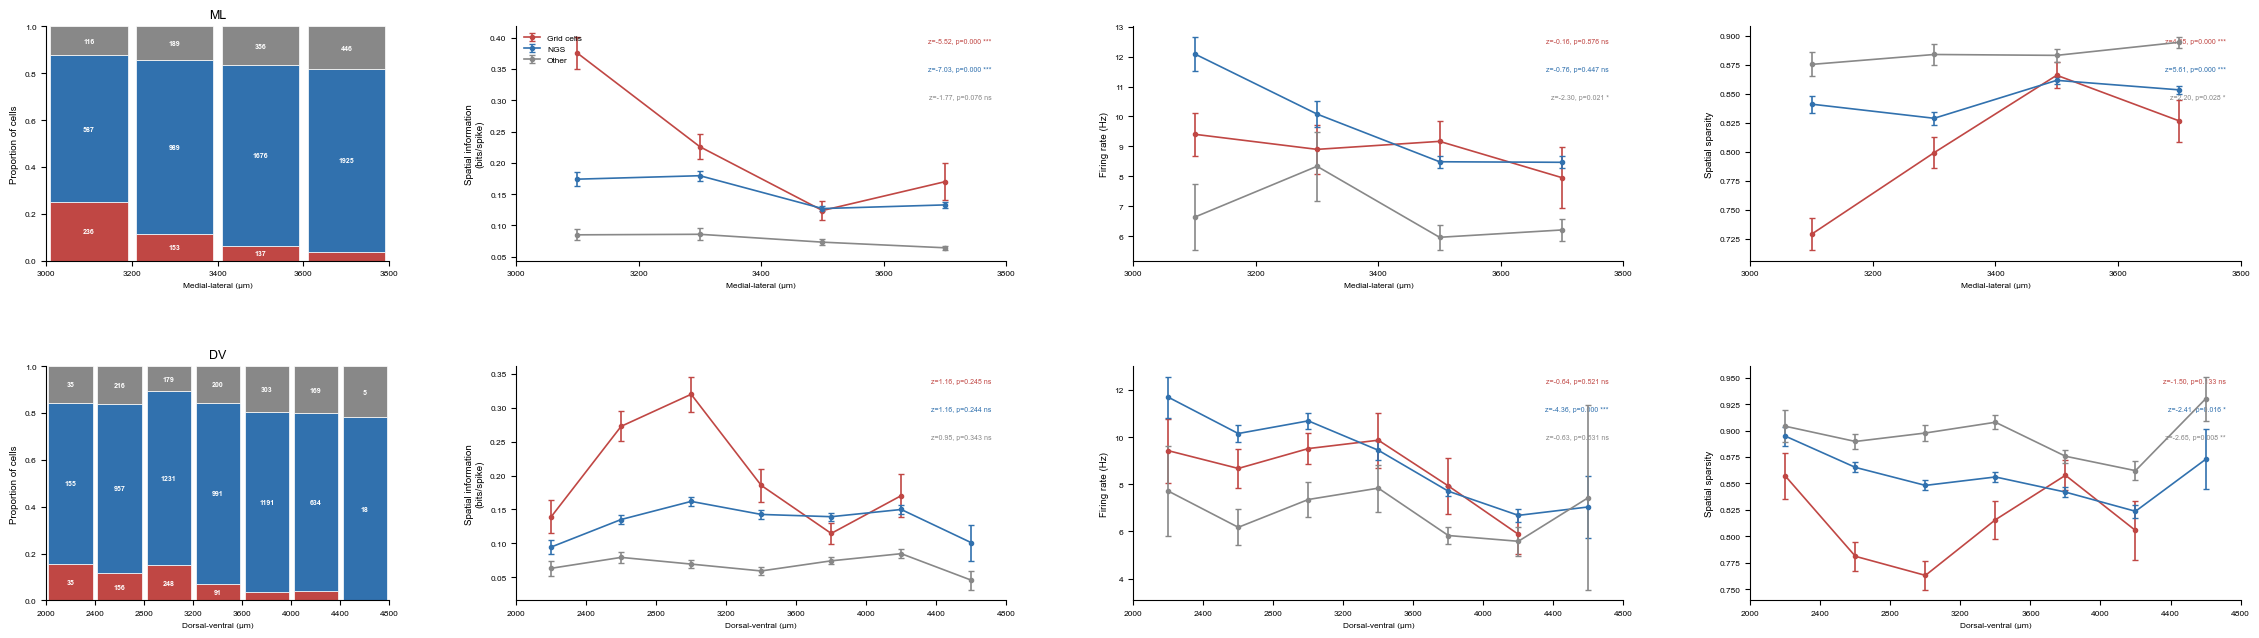

Saved → /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/mec_ml_dv_lmm_summary.pdf


In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

plt.rcParams['font.family'] = 'Arial'

COL_GC    = '#c04744'
COL_NGS   = '#3171ae'
COL_OTHER = '#888888'

# ── Data: MEC cells only ─────────────────────────────────────────────────────
_cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_cc = _cc[_cc['mouse'] != 22]
_cc = _cc[_cc['brain_region'].str.contains('ENTm', case=False, na=False)].copy()

sparsity_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/spatial_sparsity_cache.csv')
_cc = _cc.merge(sparsity_df[['mouse', 'day', 'cluster_id', 'sparsity']],
                on=['mouse', 'day', 'cluster_id'], how='left')

def get_cell_group(row):
    if row['cell_type'] == 'GC':
        return 'GC'
    elif row['cell_type'] == 'NG':
        return 'NGS'
    return 'Other'

_cc['_group'] = _cc.apply(get_cell_group, axis=1)

def get_layer_num(region):
    if not isinstance(region, str): return None
    r = region.upper()
    for l, v in [('ENTM1', 1), ('ENTM2', 2), ('ENTM3', 3), ('ENTM5', 5), ('ENTM6', 6)]:
        if l in r: return v
    return None

_cc['layer_num'] = _cc['brain_region'].apply(get_layer_num)
_cc = _cc[_cc['layer_num'].notna()].copy()
_cc['deep'] = _cc['layer_num'].isin([5, 6]).astype(int)  # superficial: ENTm1-3, deep: ENTm5-6

_cc['ml'] = _cc['SC_x'].abs()
_cc['dv'] = _cc['SC_y']
_cc['si'] = _cc['spatial_information_score_of1']
_cc['fr'] = _cc['firing_rate_OF1']
# 'sparsity' already merged in

_cc['_mouse'] = _cc['mouse'].astype(int)
_cc['_session'] = _cc['_mouse'].astype(str) + '_' + _cc['day'].astype(int).astype(str)
_cc['_cluster_uid'] = _cc['_session'] + '_' + _cc['cluster_id'].astype(int).astype(str)

_cc['ml_z'] = (_cc['ml'] - _cc['ml'].mean()) / _cc['ml'].std()
_cc['dv_z'] = (_cc['dv'] - _cc['dv'].mean()) / _cc['dv'].std()

ML_BINS = np.arange(3000, 3801, 200)
DV_BINS = np.arange(2000, 4801, 400)

cell_groups = [
    ('Grid cells', 'GC',    COL_GC),
    ('NGS',        'NGS',   COL_NGS),
    ('Other',      'Other', COL_OTHER),
]
cat_order = ['GC', 'NGS', 'Other']
cat_colors = {'GC': COL_GC, 'NGS': COL_NGS, 'Other': COL_OTHER}

measures = [
    ('Spatial information\n(bits/spike)', 'si'),
    ('Firing rate (Hz)', 'fr'),
    ('Spatial sparsity', 'sparsity'),
]

print(f"MEC cells: {len(_cc)}")
for label, key, _ in cell_groups:
    print(f"  {label}: {(_cc['_group'] == key).sum()}")

# ── Helpers ──────────────────────────────────────────────────────────────────
def pval_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

def set_bin_xticks(ax, box_bins):
    ax.set_xticks(box_bins)
    ax.set_xticklabels([f'{int(b)}' for b in box_bins], fontsize=6)

def binned_raw_stats(df_g, real_col, box_bins, value_col):
    centres = (box_bins[:-1] + box_bins[1:]) / 2
    means, sems = [], []
    for bi in range(len(box_bins) - 1):
        mask = (df_g[real_col] >= box_bins[bi]) & (df_g[real_col] < box_bins[bi + 1])
        vals = df_g.loc[mask, value_col].dropna()
        if len(vals) == 0:
            means.append(np.nan); sems.append(np.nan)
        else:
            means.append(vals.mean())
            sems.append(vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0)
    return centres, np.array(means), np.array(sems)

def annotate_stats(ax, result, term, color='black', y_pos=0.95):
    p = result.pvalues.get(term, np.nan)
    coef = result.fe_params.get(term, np.nan)
    se = result.bse.get(term, np.nan)
    stars = pval_to_stars(p)
    z_stat = coef / se if se > 0 else np.nan
    ax.annotate(f'z={z_stat:.2f}, p={p:.3f} {stars}',
                xy=(0.97, y_pos), xycoords='axes fraction',
                ha='right', va='top', fontsize=5, color=color)

# ── LMM fits: metric ~ ml_z + dv_z + deep, hierarchical Mouse / Day / cluster ──
# groups = mouse (top level); variance components = day (session within mouse)
# and cluster (cluster within day within mouse) — 'deep' (superficial vs deep
# MEC layer) included as a fixed effect to control for it as a confound.
fitted = {}
for label, key, color in cell_groups:
    sub = _cc[_cc['_group'] == key]
    fitted[key] = {'df': sub, 'color': color, 'label': label, 'models': {}}

    for measure_label, dv_col in measures:
        df_m = sub[sub[dv_col].notna()].copy()
        if len(df_m) < 30:
            print(f"  {label} {measure_label}: too few cells ({len(df_m)}), skipping")
            fitted[key]['models'][dv_col] = None
            continue
        vc = {"day": "0 + C(_session)", "cluster": "0 + C(_cluster_uid)"}
        formula = f"{dv_col} ~ ml_z + dv_z + deep"
        try:
            model = smf.mixedlm(formula, df_m, groups=df_m["_mouse"], vc_formula=vc)
            result = model.fit(method="powell", maxiter=5000, disp=False)
            fitted[key]['models'][dv_col] = result
            print(f"  {label} {measure_label}: fit (n={len(df_m)})")
        except Exception as e:
            print(f"  {label} {measure_label}: LMM failed ({e})")
            fitted[key]['models'][dv_col] = None

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE — 2 rows (ML, DV) x 4 columns (proportions, SI, FR, sparsity)
# Total width matches the ratemaps + best-fit-slice figure above.
# ══════════════════════════════════════════════════════════════════════════════
fig_w = 23.1
fig_h = 7.0

fig = plt.figure(figsize=(fig_w, fig_h))
gs = gridspec.GridSpec(2, 4, figure=fig, width_ratios=[0.7, 1, 1, 1],
                       wspace=0.28, hspace=0.45, top=0.92, bottom=0.10, left=0.03, right=0.98)

axes_info = [
    ('ML', 'ml', 'Medial-lateral (µm)', ML_BINS, 'ml_z'),
    ('DV', 'dv', 'Dorsal-ventral (µm)', DV_BINS, 'dv_z'),
]

for row_idx, (axis_label, real_col, xlabel, bins, term) in enumerate(axes_info):
    # ── Column 0: proportion of cells per bin (MEC only) ────────────────────
    ax_prop = fig.add_subplot(gs[row_idx, 0])
    centres = (bins[:-1] + bins[1:]) / 2
    bin_w = (bins[1] - bins[0]) * 0.9
    for bi in range(len(bins) - 1):
        mask = (_cc[real_col] >= bins[bi]) & (_cc[real_col] < bins[bi + 1])
        bin_cells = _cc[mask]
        total = len(bin_cells)
        if total == 0:
            continue
        bottom = 0
        for cat in cat_order:
            n = (bin_cells['_group'] == cat).sum()
            frac = n / total
            ax_prop.bar(centres[bi], frac, width=bin_w, bottom=bottom,
                        color=cat_colors[cat], edgecolor='white', lw=0.5)
            if frac > 0.05:
                ax_prop.text(centres[bi], bottom + frac / 2, f'{n}', ha='center', va='center',
                             fontsize=5, color='white', fontweight='bold')
            bottom += frac
    ax_prop.set_xlim(bins[0], bins[-1])
    set_bin_xticks(ax_prop, bins)
    ax_prop.set_ylim(0, 1)
    ax_prop.set_ylabel('Proportion of cells', fontsize=7)
    ax_prop.set_title(axis_label, fontsize=9)
    ax_prop.set_xlabel(xlabel, fontsize=6)
    ax_prop.spines[['top', 'right']].set_visible(False)
    ax_prop.tick_params(labelsize=6)

    # ── Columns 1-3: SI / FR / sparsity vs this axis, per cell-type group ───
    for col_idx, (measure_label, dv_col) in enumerate(measures):
        ax = fig.add_subplot(gs[row_idx, col_idx + 1])
        stat_y_offset = 0
        for g_label, g_key, g_color in cell_groups:
            df_g = fitted[g_key]['df']
            best_m = fitted[g_key]['models'].get(dv_col)
            if df_g[dv_col].notna().sum() == 0:
                continue
            centres_g, means, sems = binned_raw_stats(df_g, real_col, bins, dv_col)
            ax.errorbar(centres_g, means, yerr=sems, fmt='-o', color=g_color, lw=1.2,
                        markersize=3, capsize=2, zorder=3, label=g_label)
            if best_m is not None:
                annotate_stats(ax, best_m, term, color=g_color, y_pos=0.95 - stat_y_offset)
                stat_y_offset += 0.12
        ax.set_xlim(bins[0], bins[-1])
        set_bin_xticks(ax, bins)
        ax.set_ylabel(measure_label, fontsize=7)
        ax.set_xlabel(xlabel, fontsize=6)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=6)
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=6, frameon=False, loc='upper left')

out_path = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/mec_ml_dv_lmm_summary.pdf'
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved → {out_path}")


Cell counts per region / group:
_region_cat  _group    
MEC          Grid cells     616
             NGS           5177
             Other         1107
PRE/PARA     Grid cells      71
             NGS            372
             Other          106
VIS          Grid cells      56
             NGS           1027
             Other          371
dtype: int64


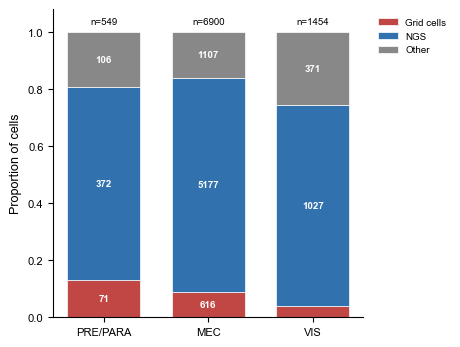

Saved → /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/region_celltype_proportions.pdf


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['font.family'] = 'Arial'

COL_GC    = '#c04744'
COL_NGS   = '#3171ae'
COL_OTHER = '#888888'

_df = load_classifications_v2()
_df = _df[_df['mouse'] != 22]

def region_category(r):
    if not isinstance(r, str):
        return None
    if r.startswith('ENTm'):
        return 'MEC'
    if r.startswith('PRE') or r.startswith('PAR'):
        return 'PRE/PARA'
    if r.startswith('VIS'):
        return 'VIS'
    return None

_df['_region_cat'] = _df['brain_region'].apply(region_category)
_df = _df[_df['_region_cat'].notna()].copy()

def cell_group(row):
    if row['cell_type'] == 'GC':
        return 'Grid cells'
    elif row['cell_type'] == 'NG':
        return 'NGS'
    return 'Other'

_df['_group'] = _df.apply(cell_group, axis=1)

region_order = ['PRE/PARA', 'MEC', 'VIS']
group_order = ['Grid cells', 'NGS', 'Other']
group_colors = {'Grid cells': COL_GC, 'NGS': COL_NGS, 'Other': COL_OTHER}

print("Cell counts per region / group:")
print(_df.groupby(['_region_cat', '_group']).size())

fig, ax = plt.subplots(figsize=(4, 4))
for i, region in enumerate(region_order):
    sub = _df[_df['_region_cat'] == region]
    total = len(sub)
    bottom = 0
    for group in group_order:
        n = (sub['_group'] == group).sum()
        frac = n / total if total > 0 else 0
        ax.bar(i, frac, width=0.7, bottom=bottom, color=group_colors[group],
               edgecolor='white', lw=0.5, label=group if i == 0 else None)
        if frac > 0.05:
            ax.text(i, bottom + frac / 2, f'{n}', ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')
        bottom += frac
    ax.text(i, 1.02, f'n={total}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(range(len(region_order)))
ax.set_xticklabels(region_order, fontsize=9)
ax.set_ylabel('Proportion of cells', fontsize=9)
ax.set_ylim(0, 1.08)
ax.legend(fontsize=7, frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1))
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=8)

out_path = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/region_celltype_proportions.pdf'
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved → {out_path}")


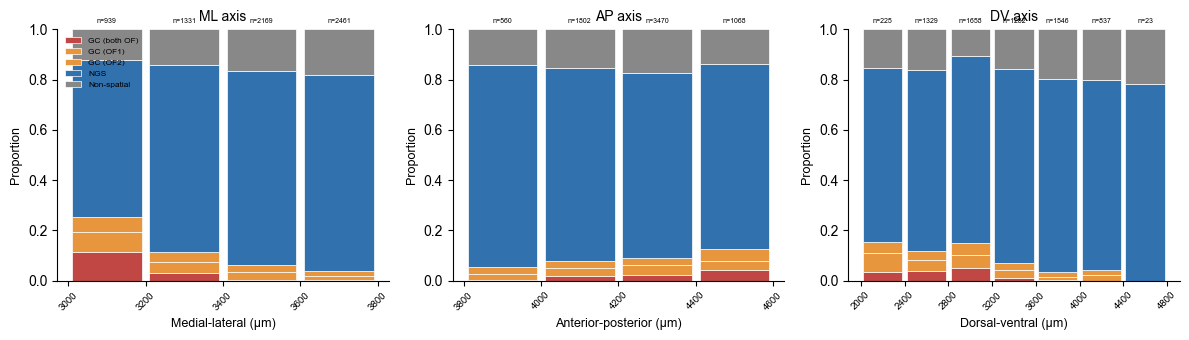

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['font.family'] = 'Arial'

_cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_cc = _cc[_cc['mouse'] != 22]
_cc = _cc[_cc['brain_region'].str.contains('ENTm', case=False, na=False)].copy()
_cc['ml'] = _cc['SC_x'].abs()
_cc['dv'] = _cc['SC_y']
_cc['ap'] = _cc['SC_z']

# Assign category
cats = []
for _, row in _cc.iterrows():
    if row['cell_type'] == 'GC':
        cb = row.get('classified_by', 'OF1')
        cats.append(cb if cb in ('both', 'OF1', 'OF2') else 'OF1')
    elif row['cell_type'] == 'NG':
        cats.append('NGS')
    else:
        cats.append('Other')
_cc['_cat'] = cats

cat_order = ['both', 'OF1', 'OF2', 'NGS', 'Other']
cat_colors = {'both': '#c04744', 'OF1': '#e8963e', 'OF2': '#e8963e', 'NGS': '#3171ae', 'Other': '#888888'}
cat_labels = {'both': 'GC (both OF)', 'OF1': 'GC (OF1)', 'OF2': 'GC (OF2)', 'NGS': 'NGS', 'Other': 'Non-spatial'}

ml_bins = np.arange(3000, 3901, 200)
ap_bins = np.arange(3800, 4701, 200)
dv_bins = np.arange(2000, 4801, 400)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for col_idx, (pos_col, bins, xlabel, axis_name) in enumerate([
    ('ml', ml_bins, 'Medial-lateral (µm)', 'ML'),
    ('ap', ap_bins, 'Anterior-posterior (µm)', 'AP'),
    ('dv', dv_bins, 'Dorsal-ventral (µm)', 'DV'),
]):
    ax = axes[col_idx]
    centres = (bins[:-1] + bins[1:]) / 2
    bar_w = (bins[1] - bins[0]) * 0.9

    _cc['_bin'] = pd.cut(_cc[pos_col], bins=bins, right=False)

    counts = _cc.groupby(['_bin', '_cat']).size().unstack(fill_value=0)
    for c in cat_order:
        if c not in counts.columns:
            counts[c] = 0
    counts = counts[cat_order]
    proportions = counts.div(counts.sum(axis=1), axis=0)

    bottom = np.zeros(len(proportions))
    for cat in cat_order:
        vals = proportions[cat].values
        ax.bar(centres, vals, width=bar_w, bottom=bottom,
               color=cat_colors[cat], label=cat_labels[cat],
               edgecolor='white', lw=0.5)
        bottom += vals

    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Proportion', fontsize=9)
    ax.set_title(f'{axis_name} axis', fontsize=10)
    ax.set_xticks(bins)
    ax.set_xticklabels([f'{int(e)}' for e in bins], fontsize=7, rotation=45)
    ax.set_ylim(0, 1)
    ax.spines[['top', 'right']].set_visible(False)

    for j, (centre, total) in enumerate(zip(centres, counts.sum(axis=1).values)):
        ax.text(centre, 1.02, f'n={int(total)}', ha='center', va='bottom', fontsize=5)

    if col_idx == 0:
        ax.legend(fontsize=6, loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/entm_cell_type_proportions_3axes.pdf',
            bbox_inches='tight', dpi=300)
plt.show()

_cc.drop(columns=['_cat', '_bin'], inplace=True)


In [5]:
device_contacts = pd.read_csv('/Users/harryclark/Downloads/device_contact_id_annotations.csv')
device_contacts['coord_SCs_x'] = np.abs(device_contacts['coord_SCs_x'])

Example cell: M25D24 c152, GS=1.44, both
D24: 10 GC + 14 NGS = 24
D19: 6 GC + 18 NGS = 24
D22: 3 GC + 21 NGS = 24
D23: 1 GC + 23 NGS = 24


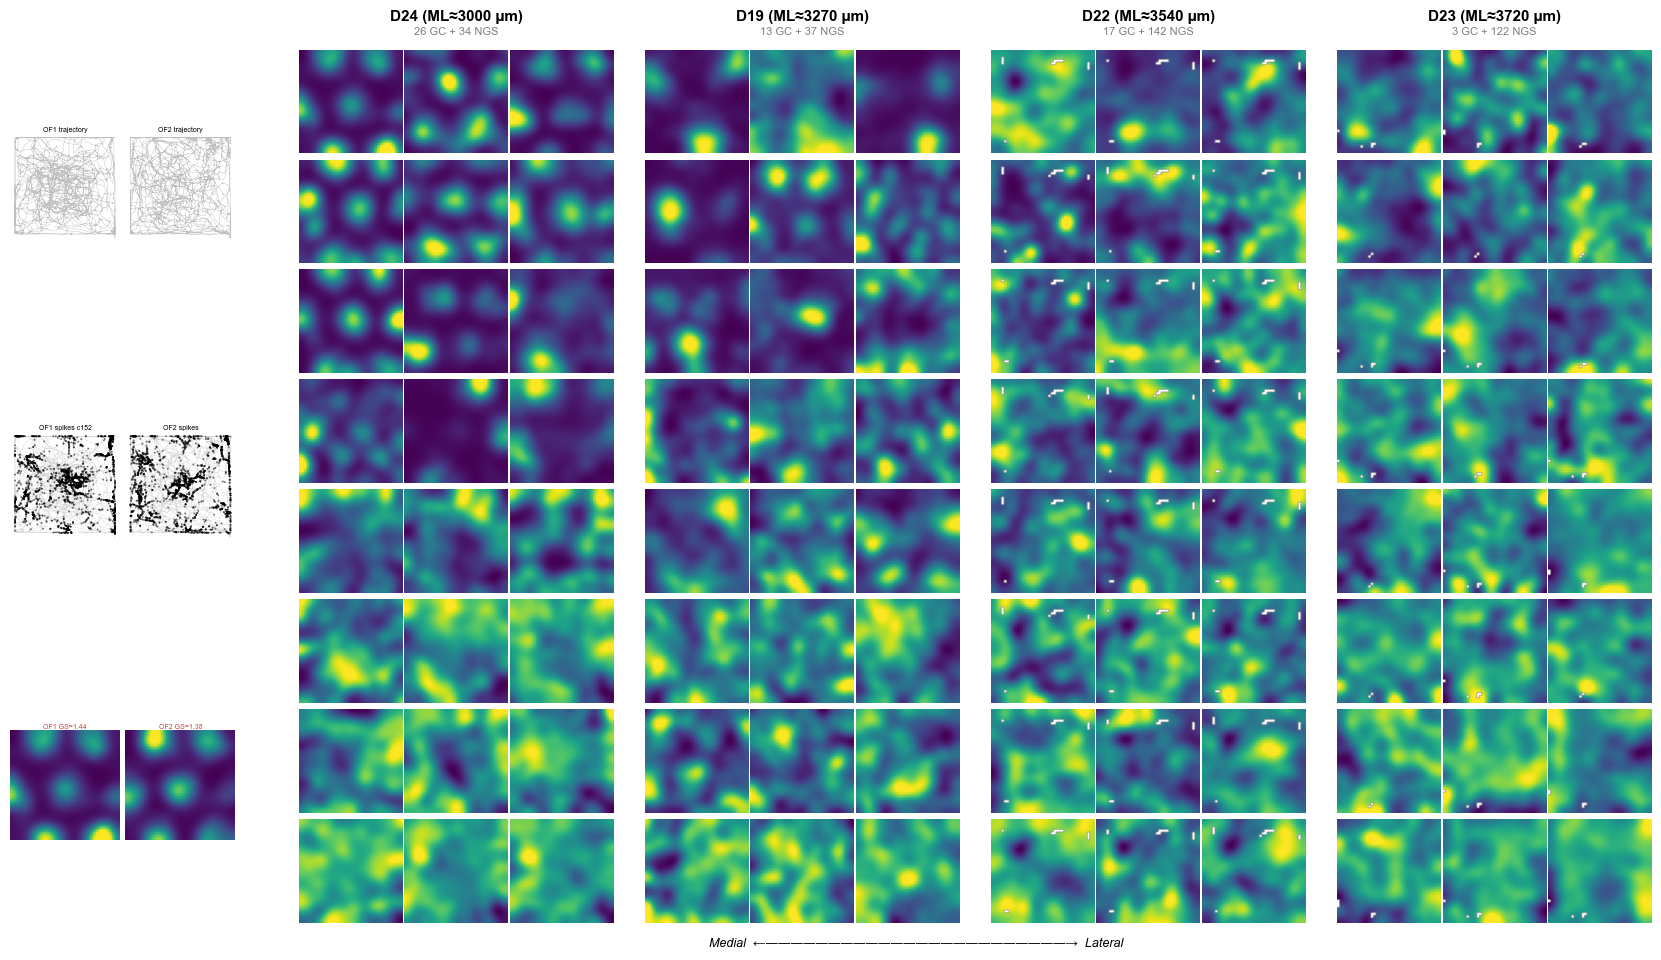

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import pynapple as nap
from spatial_manifolds.detect_grids import (
    compute_travel_projected, gaussian_filter_nan, _fill_nans_from_neighbors,
)

SOURCE_PATH = '/Users/harryclark/Downloads/clark2025/'
COL_BOTH   = '#c04744'
COL_EITHER = '#e8963e'
COL_NGS    = '#3171ae'
SPEED_THRESHOLD = 50

def _load_beh_clusters(mouse, day, session, source_path=SOURCE_PATH):
    folder = f'{source_path}M{int(mouse)}/D{int(day):02}/{session}/'
    spikes_path = folder + f"sub-{int(mouse)}_day-{int(day):02}_ses-{session}_srt-kilosort4_clusters.npz"
    beh_path = folder + f"sub-{int(mouse)}_day-{int(day):02}_ses-{session}_beh.nwb"
    beh = nap.load_file(beh_path)
    clusters = nap.load_file(spikes_path)
    return beh, clusters

def _get_speed_mask(beh, threshold=SPEED_THRESHOLD):
    px = np.array(beh['P_x'])
    py = np.array(beh['P_y'])
    times = beh['P_x'].times()
    dt = np.diff(times)
    dx = np.diff(px)
    dy = np.diff(py)
    speed = np.sqrt(dx**2 + dy**2) / dt
    speed_full = np.concatenate([[0], speed])
    return speed_full < threshold

def plot_of_rate_map(ax, cluster_id, mouse, day, df, session='OF1', source_path=SOURCE_PATH):
    beh, clusters = _load_beh_clusters(mouse, day, session, source_path)
    optimal_lag = df[df.cluster_id == cluster_id].travel.values[0]
    position = np.stack([beh['P_x'], beh['P_y']], axis=1)
    beh_lag = compute_travel_projected(["P_x", "P_y"], position, position, optimal_lag)
    position_lagged = np.stack([beh_lag['P_x'], beh_lag['P_y']], axis=1)
    tc = nap.compute_2d_tuning_curves(nap.TsGroup([clusters[cluster_id]]), position_lagged, nb_bins=(40, 40))[0][0]
    tc = _fill_nans_from_neighbors(tc)
    tc = gaussian_filter_nan(tc, sigma=(2.5, 2.5))
    tc = np.clip(tc, a_min=0, a_max=np.nanpercentile(tc, 99))
    ax.imshow(tc, cmap='viridis')
    ax.axis('off')

def plot_trajectory(ax, mouse, day, session, source_path=SOURCE_PATH):
    beh, _ = _load_beh_clusters(mouse, day, session, source_path)
    px = np.array(beh['P_x']).copy()
    py = np.array(beh['P_y']).copy()
    mask = _get_speed_mask(beh)
    px[~mask] = np.nan
    py[~mask] = np.nan
    ax.plot(px, py, color='grey', lw=0.3, alpha=0.5)
    ax.set_aspect('equal')
    ax.axis('off')

def plot_spike_positions(ax, cluster_id, mouse, day, session, source_path=SOURCE_PATH, color='black'):
    beh, clusters = _load_beh_clusters(mouse, day, session, source_path)
    px = np.array(beh['P_x']).copy()
    py = np.array(beh['P_y']).copy()
    pos_times = beh['P_x'].times()
    mask = _get_speed_mask(beh)
    px_traj = px.copy()
    py_traj = py.copy()
    px_traj[~mask] = np.nan
    py_traj[~mask] = np.nan
    ax.plot(px_traj, py_traj, color='grey', lw=0.3, alpha=0.3)
    spike_times = clusters[cluster_id].times()
    spike_idx = np.searchsorted(pos_times, spike_times)
    spike_idx = spike_idx[spike_idx < len(px)]
    spike_mask = mask[spike_idx]
    spike_idx = spike_idx[spike_mask]
    ax.scatter(px[spike_idx], py[spike_idx], c=color, s=2, alpha=0.5, zorder=3, edgecolors='none')
    ax.set_aspect('equal')
    ax.axis('off')

_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')

mouse = 25
sessions = [24, 19, 22, 23]
N_TOTAL = 24
N_COLS_PER_SESSION = 3
N_ROWS = N_TOTAL // N_COLS_PER_SESSION

example_day = 24
example_gc = _df[(_df['mouse'] == mouse) & (_df['day'] == example_day) & (_df['cell_type'] == 'GC')]
example_gc = example_gc.sort_values('grid_score_best', ascending=False)
example_cid = int(example_gc.iloc[0]['cluster_id'])
example_cb = example_gc.iloc[0]['classified_by']
example_gs = example_gc.iloc[0]['grid_score_best']
print(f"Example cell: M{mouse}D{example_day} c{example_cid}, GS={example_gs:.2f}, {example_cb}")

np.random.seed(42)

session_cells = {}
session_counts = {}

for day in sessions:
    sub = _df[(_df['mouse'] == mouse) & (_df['day'] == day)]
    gc = sub[sub['cell_type'] == 'GC'].copy()
    gc['ml'] = gc['SC_x'].abs()
    ngs = sub[sub['cell_type'] == 'NG'].copy()
    ngs['ml'] = ngs['SC_x'].abs()
    other = sub[sub['cell_type'] == 'Other']

    session_counts[day] = {
        'GC_both': len(gc[gc['classified_by'] == 'both']),
        'GC_either': len(gc[gc['classified_by'].isin(['OF1', 'OF2'])]),
        'NGS': len(ngs),
        'Other': len(other),
        'Total': len(sub),
    }

    total = len(gc) + len(ngs)
    n_gc = round((len(gc) / total) * N_TOTAL) if total > 0 else 0
    n_gc = max(n_gc, min(1, len(gc)))
    n_ngs = N_TOTAL - n_gc

    gc = gc.sort_values('grid_score_best', ascending=False)
    if len(gc) > n_gc:
        gc = gc.head(n_gc)

    ngs_sorted_dv = ngs.sort_values('SC_y')
    if len(ngs_sorted_dv) > n_ngs:
        idx = np.linspace(0, len(ngs_sorted_dv) - 1, n_ngs).astype(int)
        ngs = ngs_sorted_dv.iloc[idx]
    else:
        ngs = ngs_sorted_dv
    ngs = ngs.sort_values('spatial_information_score_best', ascending=False)

    gc = gc.copy()
    ngs = ngs.copy()
    gc['_type'] = 'GC'
    ngs['_type'] = 'NGS'
    combined = pd.concat([gc, ngs]).reset_index(drop=True)
    session_cells[day] = combined
    print(f'D{day}: {len(gc)} GC + {len(ngs)} NGS = {len(combined)}')

n_example_cols = 2
total_right_cols = len(sessions) * N_COLS_PER_SESSION

fig = plt.figure(figsize=(n_example_cols * 1.2 + 0.3 + total_right_cols * 1.2, N_ROWS * 1.2))
outer = gridspec.GridSpec(1, 2, figure=fig, wspace=0.08,
                          width_ratios=[n_example_cols, total_right_cols],
                          top=0.94, bottom=0.03, left=0.02, right=0.98)

left_gs = outer[0, 0].subgridspec(3, 2, wspace=0.05, hspace=0.08)

ax_traj_of1 = fig.add_subplot(left_gs[0, 0])
ax_traj_of2 = fig.add_subplot(left_gs[0, 1])
plot_trajectory(ax_traj_of1, mouse, example_day, 'OF1')
ax_traj_of1.set_title('OF1 trajectory', fontsize=5, pad=1)
plot_trajectory(ax_traj_of2, mouse, example_day, 'OF2')
ax_traj_of2.set_title('OF2 trajectory', fontsize=5, pad=1)

ax_spk_of1 = fig.add_subplot(left_gs[1, 0])
ax_spk_of2 = fig.add_subplot(left_gs[1, 1])
plot_spike_positions(ax_spk_of1, example_cid, mouse, example_day, 'OF1', color='black')
ax_spk_of1.set_title(f'OF1 spikes c{example_cid}', fontsize=5, pad=1, color='black')
plot_spike_positions(ax_spk_of2, example_cid, mouse, example_day, 'OF2', color='black')
ax_spk_of2.set_title(f'OF2 spikes', fontsize=5, pad=1, color='black')

ax_rm_of1 = fig.add_subplot(left_gs[2, 0])
ax_rm_of2 = fig.add_subplot(left_gs[2, 1])
plot_of_rate_map(ax_rm_of1, example_cid, mouse, example_day, _df, session='OF1')
ax_rm_of1.set_title(f'OF1 GS={example_gs:.2f}', fontsize=5, pad=1, color=COL_BOTH)
plot_of_rate_map(ax_rm_of2, example_cid, mouse, example_day, _df, session='OF2')
gs_of2 = example_gc.iloc[0].get('grid_score_of2', np.nan)
ax_rm_of2.set_title(f'OF2 GS={gs_of2:.2f}', fontsize=5, pad=1, color=COL_BOTH)

right_gs = outer[0, 1].subgridspec(1, len(sessions), wspace=0.1)

for s_idx, day in enumerate(sessions):
    cells = session_cells[day]
    ml_val = cells['ml'].iloc[0] if len(cells) > 0 else 0
    counts = session_counts[day]

    inner = right_gs[0, s_idx].subgridspec(N_ROWS, N_COLS_PER_SESSION, wspace=0.02, hspace=0.06)

    mid_x = (right_gs[0, s_idx].get_position(fig).x0 + right_gs[0, s_idx].get_position(fig).x1) / 2
    fig.text(mid_x, 0.97, f'D{day} (ML≈{ml_val:.0f} µm)',
             ha='center', fontsize=11, weight='bold')
    fig.text(mid_x, 0.955, f'{counts["GC_both"]+counts["GC_either"]} GC + {counts["NGS"]} NGS',
             ha='center', fontsize=8, color='grey')

    for idx in range(min(len(cells), N_TOTAL)):
        r = idx // N_COLS_PER_SESSION
        c = idx % N_COLS_PER_SESSION
        ax = fig.add_subplot(inner[r, c])

        ex = cells.iloc[idx]
        cid = int(ex.cluster_id)
        cell_type = ex['_type']

        try:
            plot_of_rate_map(ax, cid, mouse, day, _df, session='OF1')
        except Exception as e:
            ax.text(0.5, 0.5, '—', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='grey')
            ax.axis('off')
            print(f"  Failed M{mouse}D{day} c{cid}: {e}")

    for idx in range(len(cells), N_ROWS * N_COLS_PER_SESSION):
        r = idx // N_COLS_PER_SESSION
        c = idx % N_COLS_PER_SESSION
        ax = fig.add_subplot(inner[r, c])
        ax.axis('off')

fig.text(0.55, 0.005, 'Medial  ←――――――――――――――――――――――――→  Lateral',
         ha='center', fontsize=9, style='italic')

plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/M25_proportional_gc_ngs_with_example.pdf',
            bbox_inches='tight', dpi=300)
plt.show()


ENTm cells: 6900
  Grid cells: 616
  NGS: 5177
  Other: 1107
  Grid cells Spatial information (bits / spike): fit (n=616)
  Grid cells Firing rate (Hz): fit (n=616)
  Grid cells Spatial sparsity: fit (n=616)


/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


  NGS Spatial information (bits / spike): fit (n=5177)
  NGS Firing rate (Hz): fit (n=5177)
  NGS Spatial sparsity: fit (n=5177)


/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


  Other Spatial information (bits / spike): fit (n=1107)
  Other Firing rate (Hz): fit (n=1107)
  Other Spatial sparsity: fit (n=1107)


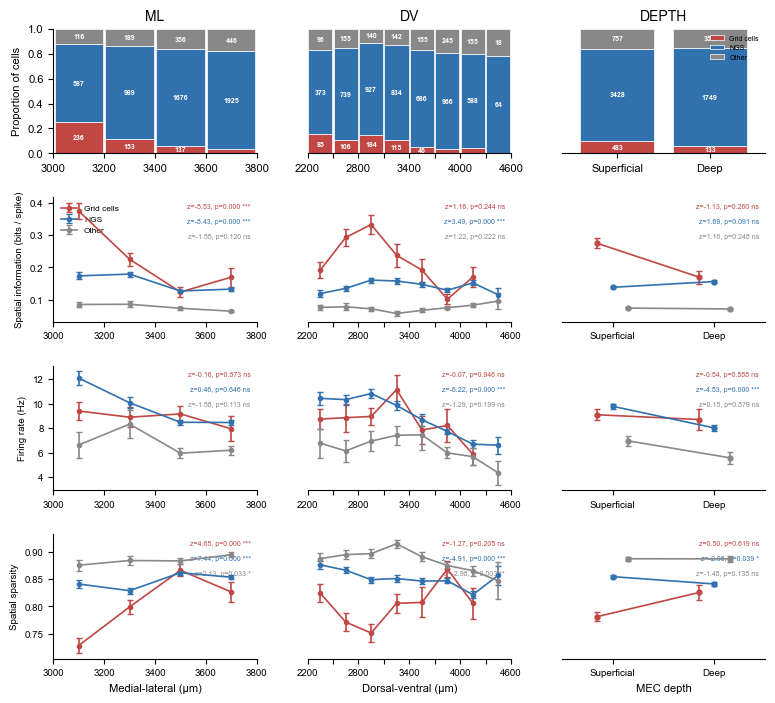

In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

plt.rcParams['font.family'] = 'Arial'

COL_GC    = '#c04744'
COL_NGS   = '#3171ae'
COL_OTHER = '#888888'

_cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_cc = _cc[_cc['mouse'] != 22]
_cc = _cc[_cc['brain_region'].str.contains('ENTm', case=False, na=False)].copy()

sparsity_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/spatial_sparsity_cache.csv')
_cc = _cc.merge(sparsity_df[['mouse', 'day', 'cluster_id', 'sparsity']],
                on=['mouse', 'day', 'cluster_id'], how='left')

def get_cell_group(row):
    if row['cell_type'] == 'GC':
        return 'GC'
    elif row['cell_type'] == 'NG':
        return 'NGS'
    return 'Other'

_cc['_group'] = _cc.apply(get_cell_group, axis=1)

def get_layer_num(region):
    if not isinstance(region, str): return None
    r = region.upper()
    for l, v in [('ENTM1', 1), ('ENTM2', 2), ('ENTM3', 3), ('ENTM5', 5), ('ENTM6', 6)]:
        if l in r: return v
    return None

_cc['layer_num'] = _cc['brain_region'].apply(get_layer_num)
_cc = _cc[_cc['layer_num'].notna()].copy()
_cc['depth'] = np.where(_cc['layer_num'].isin([1, 2, 3]), 'Superficial', 'Deep')
_cc['deep'] = (_cc['layer_num'].isin([5, 6])).astype(int)

# Prepare subsets — grid cells not split by classified_by (both/either merged)
cell_groups = [
    ('Grid cells', 'GC',    COL_GC),
    ('NGS',        'NGS',   COL_NGS),
    ('Other',      'Other', COL_OTHER),
]

def prepare_df(cc_sub):
    d = cc_sub.copy()
    d['ml'] = d['SC_x'].abs()
    d['dv'] = d['SC_y']
    d['si'] = d['spatial_information_score_of1']
    d['fr'] = d['firing_rate_OF1']
    d['_mouse'] = d['mouse'].astype(int)
    d['_session'] = d['_mouse'].astype(str) + '_' + d['day'].astype(int).astype(str)
    d['ml_z'] = (d['ml'] - d['ml'].mean()) / d['ml'].std()
    d['dv_z'] = (d['dv'] - d['dv'].mean()) / d['dv'].std()
    return d

# Also prepare all-cells df for proportions
df_all = _cc.copy()
df_all['ml'] = df_all['SC_x'].abs()
df_all['dv'] = df_all['SC_y']
df_all['_prop_cat'] = df_all['_group']

print(f"ENTm cells: {len(_cc)}")
for label, key, _ in cell_groups:
    print(f"  {label}: {(_cc['_group'] == key).sum()}")

# ── Helpers ──────────────────────────────────────────────────────────────────
def pval_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

def fit_model(dv_col, df_fit):
    vc = {"session": "0 + C(_session)"}
    formula = f"{dv_col} ~ ml_z + dv_z + deep + ml_z:deep + dv_z:deep + ml_z:dv_z"
    m = smf.mixedlm(formula, df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    return m.fit(method="powell", maxiter=5000, disp=False)

def annotate_stats(ax, result, term, color='black', y_pos=0.95):
    p = result.pvalues.get(term, np.nan)
    coef = result.fe_params.get(term, np.nan)
    se = result.bse.get(term, np.nan)
    stars = pval_to_stars(p)
    z_stat = coef / se if se > 0 else np.nan
    ax.annotate(f'z={z_stat:.2f}, p={p:.3f} {stars}',
                xy=(0.97, y_pos), xycoords='axes fraction',
                ha='right', va='top', fontsize=5, color=color)

def set_bin_xticks(ax, box_bins, every_other=False):
    ax.set_xticks(box_bins)
    if every_other:
        ax.set_xticklabels([f'{int(b)}' if i % 2 == 0 else '' for i, b in enumerate(box_bins)],
                           fontsize=7)
    else:
        ax.set_xticklabels([f'{int(b)}' for b in box_bins], fontsize=7)

def binned_raw_stats(df_g, real_col, box_bins, value_col):
    centres = (box_bins[:-1] + box_bins[1:]) / 2
    means, sems = [], []
    for bi in range(len(box_bins) - 1):
        mask = (df_g[real_col] >= box_bins[bi]) & (df_g[real_col] < box_bins[bi + 1])
        vals = df_g.loc[mask, value_col].dropna()
        if len(vals) == 0:
            means.append(np.nan); sems.append(np.nan)
        else:
            means.append(vals.mean())
            sems.append(vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0)
    return centres, np.array(means), np.array(sems)

def depth_raw_stats(df_g, value_col):
    means, sems = [], []
    for depth in ['Superficial', 'Deep']:
        vals = df_g.loc[df_g['depth'] == depth, value_col].dropna()
        means.append(vals.mean() if len(vals) > 0 else np.nan)
        sems.append(vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0)
    return np.array(means), np.array(sems)

ML_BOX_BINS = np.arange(3000, 3801, 200)
DV_BOX_BINS = np.arange(2200, 4601, 300)

cat_order = ['GC', 'NGS', 'Other']
cat_colors_prop = {'GC': COL_GC, 'NGS': COL_NGS, 'Other': COL_OTHER}
cat_labels_prop = {'GC': 'Grid cells', 'NGS': 'NGS', 'Other': 'Other'}

all_axes_info = [
    ('ml', 'Medial-lateral (µm)', ML_BOX_BINS, False),
    ('dv', 'Dorsal-ventral (µm)', DV_BOX_BINS, True),
    ('depth', 'MEC depth', None, False),
]

measures = [
    ('Spatial information (bits / spike)', 'si'),
    ('Firing rate (Hz)', 'fr'),
    ('Spatial sparsity', 'sparsity'),
]

# ── Fit models per group per measure ─────────────────────────────────────────
fitted = {}
for label, key, color in cell_groups:
    sub = _cc[_cc['_group'] == key]
    df_sub = prepare_df(sub)
    fitted[key] = {'df': df_sub, 'color': color, 'label': label, 'models': {}}

    for measure_label, dv_col in measures:
        df_m = df_sub[df_sub[dv_col].notna()].copy()
        if len(df_m) < 30:
            print(f"  {label} {measure_label}: too few cells ({len(df_m)}), skipping")
            fitted[key]['models'][dv_col] = None
            continue
        try:
            fitted[key]['models'][dv_col] = fit_model(dv_col, df_m)
            print(f"  {label} {measure_label}: fit (n={len(df_m)})")
        except Exception as e:
            print(f"  {label} {measure_label}: GLMM failed ({e})")
            fitted[key]['models'][dv_col] = None

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(8, 7))
gs_outer = gridspec.GridSpec(4, 1, figure=fig, hspace=0.35,
                              top=0.96, bottom=0.06, left=0.08, right=0.97)

# ── Row 0: Cell type proportions ─────────────────────────────────────────────
gs_row0 = gs_outer[0].subgridspec(1, 3, wspace=0.25)
ax_prop = [fig.add_subplot(gs_row0[0, 0])]
ax_prop.append(fig.add_subplot(gs_row0[0, 1], sharey=ax_prop[0]))
ax_prop.append(fig.add_subplot(gs_row0[0, 2], sharey=ax_prop[0]))

for col_idx, (real_col, xlabel, box_bins, every_other) in enumerate(all_axes_info):
    ax = ax_prop[col_idx]

    if real_col == 'depth':
        depth_order = ['Superficial', 'Deep']
        for di, dep in enumerate(depth_order):
            depth_cells = df_all[df_all['depth'] == dep]
            total = len(depth_cells)
            if total == 0: continue
            bottom = 0
            for cat in cat_order:
                n = (depth_cells['_prop_cat'] == cat).sum()
                frac = n / total
                label = cat_labels_prop[cat] if di == 0 else None
                ax.bar(di, frac, width=0.8, bottom=bottom,
                       color=cat_colors_prop[cat], edgecolor='white', lw=0.5,
                       label=label)
                if frac > 0.05:
                    ax.text(di, bottom + frac/2, f'{n}', ha='center', va='center',
                            fontsize=5, color='white', fontweight='bold')
                bottom += frac
        ax.set_xticks(np.arange(len(depth_order)))
        ax.set_xticklabels(depth_order, fontsize=9)
        ax.set_xlim(-0.6, 1.6)
        ax.legend(fontsize=5, frameon=False, loc='upper right')
    else:
        bin_width = box_bins[1] - box_bins[0]
        centres = (box_bins[:-1] + box_bins[1:]) / 2
        for bi in range(len(box_bins) - 1):
            mask = (df_all[real_col] >= box_bins[bi]) & (df_all[real_col] < box_bins[bi + 1])
            bin_cells = df_all[mask]
            total = len(bin_cells)
            if total == 0: continue
            bottom = 0
            for cat in cat_order:
                n = (bin_cells['_prop_cat'] == cat).sum()
                frac = n / total
                ax.bar(centres[bi], frac, width=bin_width * 0.95, bottom=bottom,
                       color=cat_colors_prop[cat], edgecolor='white', lw=0.5)
                if frac > 0.05:
                    ax.text(centres[bi], bottom + frac/2, f'{n}', ha='center', va='center',
                            fontsize=5, color='white', fontweight='bold')
                bottom += frac
        ax.set_xlim(box_bins[0], box_bins[-1])
        set_bin_xticks(ax, box_bins, every_other=every_other)

    ax.set_ylim(0, 1)
    if col_idx == 0:
        ax.set_ylabel('Proportion of cells', fontsize=8)
        ax.set_title('ML', fontsize=10)
    elif col_idx == 1:
        ax.set_title('DV', fontsize=10)
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.tick_params(left=False)
        ax.spines['left'].set_visible(False)
    else:
        ax.set_title('DEPTH', fontsize=10)
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.tick_params(left=False)
        ax.spines['left'].set_visible(False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)

# ── Rows 1-3: Raw values per cell group ─────────────────────────────────────
n_groups = len(cell_groups)
dodge = 0.15

for m_idx, (measure_label, dv_col) in enumerate(measures):
    gs_row = gs_outer[m_idx + 1].subgridspec(1, 3, wspace=0.25)
    row_axes = [fig.add_subplot(gs_row[0, 0])]
    row_axes.append(fig.add_subplot(gs_row[0, 1], sharey=row_axes[0]))
    row_axes.append(fig.add_subplot(gs_row[0, 2], sharey=row_axes[0]))

    for col_idx, (real_col, xlabel, box_bins, every_other) in enumerate(all_axes_info):
        ax = row_axes[col_idx]
        term = {'ml': 'ml_z', 'dv': 'dv_z', 'depth': 'deep'}[real_col]

        stat_y_offset = 0

        for gi, (g_label, g_key, g_color) in enumerate(cell_groups):
            df_g = fitted[g_key]['df']
            best_m = fitted[g_key]['models'].get(dv_col)

            if df_g[dv_col].notna().sum() == 0:
                continue

            if real_col == 'depth':
                means, sems = depth_raw_stats(df_g, dv_col)
                offset = (gi - (n_groups - 1) / 2) * dodge
                x = np.array([0, 1]) + offset
                ax.errorbar(x, means, yerr=sems, fmt='-o', color=g_color, lw=1.2,
                             markersize=3.5, capsize=2, zorder=5, label=g_label)
            else:
                centres, means, sems = binned_raw_stats(df_g, real_col, box_bins, dv_col)
                ax.errorbar(centres, means, yerr=sems, fmt='-o', color=g_color, lw=1.2,
                             markersize=3, capsize=2, zorder=5, label=g_label)

            if best_m is not None:
                annotate_stats(ax, best_m, term, color=g_color, y_pos=0.95 - stat_y_offset)
                stat_y_offset += 0.12

        if real_col == 'depth':
            ax.set_xlim(-0.5, 1.5)
            ax.set_xticks([0, 1])
            ax.set_xticklabels(['Superficial', 'Deep'], fontsize=8)
        else:
            if box_bins is not None:
                ax.set_xlim(box_bins[0], box_bins[-1])
                set_bin_xticks(ax, box_bins, every_other=every_other)

        if col_idx == 0:
            ax.set_ylabel(measure_label, fontsize=7)
        else:
            ax.set_ylabel('')
            plt.setp(ax.get_yticklabels(), visible=False)
            ax.spines['left'].set_visible(False)
            ax.tick_params(left=False)

        if m_idx == 2:
            ax.set_xlabel(xlabel, fontsize=8)
        else:
            ax.set_xlabel('')

        if m_idx == 0 and col_idx == 0:
            ax.legend(fontsize=6, frameon=False, loc='upper left')

        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=7)

plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/cell_groups_raw_values_simple.pdf',
            bbox_inches='tight', dpi=300)
plt.show()


ENTm cells: 6900
  GC (both): 159
  GC (either): 457
  NGS: 5177
  GC (both) Spatial information (bits / spike): fit (n=159)
  GC (both) Firing rate (Hz): fit (n=159)
  GC (both) Spatial sparsity: fit (n=159)
  GC (either) Spatial information (bits / spike): fit (n=457)
  GC (either) Firing rate (Hz): fit (n=457)
  GC (either) Spatial sparsity: fit (n=457)


/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


  NGS Spatial information (bits / spike): fit (n=5177)
  NGS Firing rate (Hz): fit (n=5177)
  NGS Spatial sparsity: fit (n=5177)


/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


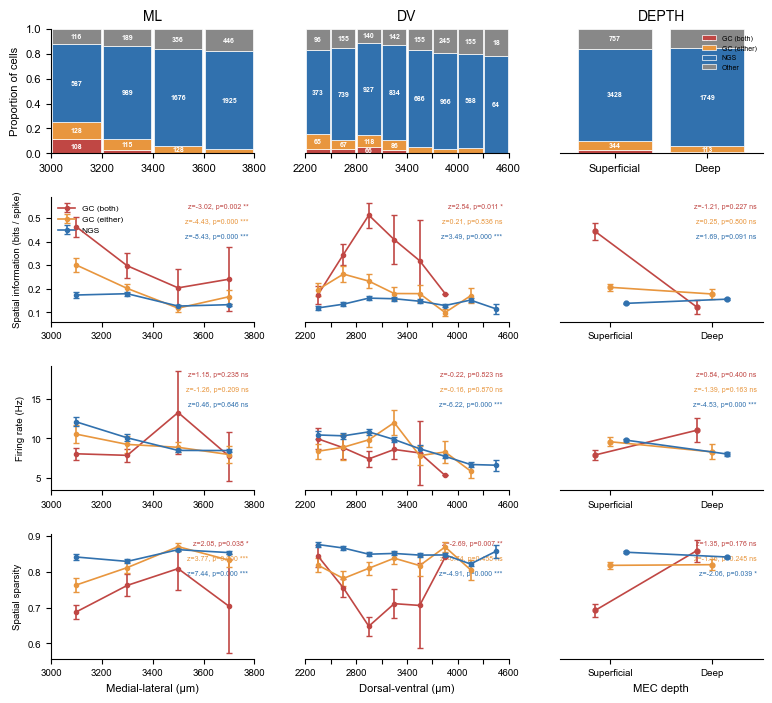

In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

plt.rcParams['font.family'] = 'Arial'

COL_NGS       = '#3171ae'
COL_GC_BOTH   = '#c04744'
COL_GC_EITHER = '#e8963e'
COL_OTHER     = '#888888'

_cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_cc = _cc[_cc['mouse'] != 22]
_cc = _cc[_cc['brain_region'].str.contains('ENTm', case=False, na=False)].copy()

sparsity_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/spatial_sparsity_cache.csv')
_cc = _cc.merge(sparsity_df[['mouse', 'day', 'cluster_id', 'sparsity']],
                on=['mouse', 'day', 'cluster_id'], how='left')

def get_cell_group(row):
    if row['cell_type'] == 'GC':
        cb = row.get('classified_by', 'OF1')
        return 'GC_both' if cb == 'both' else 'GC_either'
    elif row['cell_type'] == 'NG':
        return 'NGS'
    return 'Other'

_cc['_group'] = _cc.apply(get_cell_group, axis=1)

def get_layer_num(region):
    if not isinstance(region, str): return None
    r = region.upper()
    for l, v in [('ENTM1', 1), ('ENTM2', 2), ('ENTM3', 3), ('ENTM5', 5), ('ENTM6', 6)]:
        if l in r: return v
    return None

_cc['layer_num'] = _cc['brain_region'].apply(get_layer_num)
_cc = _cc[_cc['layer_num'].notna()].copy()
_cc['depth'] = np.where(_cc['layer_num'].isin([1, 2, 3]), 'Superficial', 'Deep')
_cc['deep'] = (_cc['layer_num'].isin([5, 6])).astype(int)

# Prepare subsets
cell_groups = [
    ('GC (both)',   'GC_both',   COL_GC_BOTH),
    ('GC (either)', 'GC_either', COL_GC_EITHER),
    ('NGS',         'NGS',       COL_NGS),
]

def prepare_df(cc_sub):
    d = cc_sub.copy()
    d['ml'] = d['SC_x'].abs()
    d['dv'] = d['SC_y']
    d['si'] = d['spatial_information_score_of1']
    d['fr'] = d['firing_rate_OF1']
    d['_mouse'] = d['mouse'].astype(int)
    d['_session'] = d['_mouse'].astype(str) + '_' + d['day'].astype(int).astype(str)
    d['ml_z'] = (d['ml'] - d['ml'].mean()) / d['ml'].std()
    d['dv_z'] = (d['dv'] - d['dv'].mean()) / d['dv'].std()
    return d

# Also prepare all-cells df for proportions
df_all = _cc.copy()
df_all['ml'] = df_all['SC_x'].abs()
df_all['dv'] = df_all['SC_y']
df_all['_prop_cat'] = df_all['_group']

print(f"ENTm cells: {len(_cc)}")
for label, key, _ in cell_groups:
    print(f"  {label}: {(_cc['_group'] == key).sum()}")

# ── Helpers ──────────────────────────────────────────────────────────────────
def pval_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

def fit_model(dv_col, df_fit):
    vc = {"session": "0 + C(_session)"}
    formula = f"{dv_col} ~ ml_z + dv_z + deep + ml_z:deep + dv_z:deep + ml_z:dv_z"
    m = smf.mixedlm(formula, df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    return m.fit(method="powell", maxiter=5000, disp=False)

def annotate_stats(ax, result, term, color='black', y_pos=0.95):
    p = result.pvalues.get(term, np.nan)
    coef = result.fe_params.get(term, np.nan)
    se = result.bse.get(term, np.nan)
    stars = pval_to_stars(p)
    z_stat = coef / se if se > 0 else np.nan
    ax.annotate(f'z={z_stat:.2f}, p={p:.3f} {stars}',
                xy=(0.97, y_pos), xycoords='axes fraction',
                ha='right', va='top', fontsize=5, color=color)

def set_bin_xticks(ax, box_bins, every_other=False):
    ax.set_xticks(box_bins)
    if every_other:
        ax.set_xticklabels([f'{int(b)}' if i % 2 == 0 else '' for i, b in enumerate(box_bins)],
                           fontsize=7)
    else:
        ax.set_xticklabels([f'{int(b)}' for b in box_bins], fontsize=7)

def binned_raw_stats(df_g, real_col, box_bins, value_col):
    centres = (box_bins[:-1] + box_bins[1:]) / 2
    means, sems = [], []
    for bi in range(len(box_bins) - 1):
        mask = (df_g[real_col] >= box_bins[bi]) & (df_g[real_col] < box_bins[bi + 1])
        vals = df_g.loc[mask, value_col].dropna()
        if len(vals) == 0:
            means.append(np.nan); sems.append(np.nan)
        else:
            means.append(vals.mean())
            sems.append(vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0)
    return centres, np.array(means), np.array(sems)

def depth_raw_stats(df_g, value_col):
    means, sems = [], []
    for depth in ['Superficial', 'Deep']:
        vals = df_g.loc[df_g['depth'] == depth, value_col].dropna()
        means.append(vals.mean() if len(vals) > 0 else np.nan)
        sems.append(vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0)
    return np.array(means), np.array(sems)

ML_BOX_BINS = np.arange(3000, 3801, 200)
DV_BOX_BINS = np.arange(2200, 4601, 300)

cat_order = ['GC_both', 'GC_either', 'NGS', 'Other']
cat_colors_prop = {'GC_both': COL_GC_BOTH, 'GC_either': COL_GC_EITHER, 'NGS': COL_NGS, 'Other': COL_OTHER}
cat_labels_prop = {'GC_both': 'GC (both)', 'GC_either': 'GC (either)', 'NGS': 'NGS', 'Other': 'Other'}

all_axes_info = [
    ('ml', 'Medial-lateral (µm)', ML_BOX_BINS, False),
    ('dv', 'Dorsal-ventral (µm)', DV_BOX_BINS, True),
    ('depth', 'MEC depth', None, False),
]

measures = [
    ('Spatial information (bits / spike)', 'si'),
    ('Firing rate (Hz)', 'fr'),
    ('Spatial sparsity', 'sparsity'),
]

# ── Fit models per group per measure ─────────────────────────────────────────
fitted = {}
for label, key, color in cell_groups:
    sub = _cc[_cc['_group'] == key]
    df_sub = prepare_df(sub)
    fitted[key] = {'df': df_sub, 'color': color, 'label': label, 'models': {}}

    for measure_label, dv_col in measures:
        df_m = df_sub[df_sub[dv_col].notna()].copy()
        if len(df_m) < 30:
            print(f"  {label} {measure_label}: too few cells ({len(df_m)}), skipping")
            fitted[key]['models'][dv_col] = None
            continue
        try:
            fitted[key]['models'][dv_col] = fit_model(dv_col, df_m)
            print(f"  {label} {measure_label}: fit (n={len(df_m)})")
        except Exception as e:
            print(f"  {label} {measure_label}: GLMM failed ({e})")
            fitted[key]['models'][dv_col] = None

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(8, 7))
gs_outer = gridspec.GridSpec(4, 1, figure=fig, hspace=0.35,
                              top=0.96, bottom=0.06, left=0.08, right=0.97)

# ── Row 0: Cell type proportions ─────────────────────────────────────────────
gs_row0 = gs_outer[0].subgridspec(1, 3, wspace=0.25)
ax_prop = [fig.add_subplot(gs_row0[0, 0])]
ax_prop.append(fig.add_subplot(gs_row0[0, 1], sharey=ax_prop[0]))
ax_prop.append(fig.add_subplot(gs_row0[0, 2], sharey=ax_prop[0]))

for col_idx, (real_col, xlabel, box_bins, every_other) in enumerate(all_axes_info):
    ax = ax_prop[col_idx]

    if real_col == 'depth':
        depth_order = ['Superficial', 'Deep']
        for di, dep in enumerate(depth_order):
            depth_cells = df_all[df_all['depth'] == dep]
            total = len(depth_cells)
            if total == 0: continue
            bottom = 0
            for cat in cat_order:
                n = (depth_cells['_prop_cat'] == cat).sum()
                frac = n / total
                label = cat_labels_prop[cat] if di == 0 else None
                ax.bar(di, frac, width=0.8, bottom=bottom,
                       color=cat_colors_prop[cat], edgecolor='white', lw=0.5,
                       label=label)
                if frac > 0.05:
                    ax.text(di, bottom + frac/2, f'{n}', ha='center', va='center',
                            fontsize=5, color='white', fontweight='bold')
                bottom += frac
        ax.set_xticks(np.arange(len(depth_order)))
        ax.set_xticklabels(depth_order, fontsize=9)
        ax.set_xlim(-0.6, 1.6)
        ax.legend(fontsize=5, frameon=False, loc='upper right')
    else:
        bin_width = box_bins[1] - box_bins[0]
        centres = (box_bins[:-1] + box_bins[1:]) / 2
        for bi in range(len(box_bins) - 1):
            mask = (df_all[real_col] >= box_bins[bi]) & (df_all[real_col] < box_bins[bi + 1])
            bin_cells = df_all[mask]
            total = len(bin_cells)
            if total == 0: continue
            bottom = 0
            for cat in cat_order:
                n = (bin_cells['_prop_cat'] == cat).sum()
                frac = n / total
                ax.bar(centres[bi], frac, width=bin_width * 0.95, bottom=bottom,
                       color=cat_colors_prop[cat], edgecolor='white', lw=0.5)
                if frac > 0.05:
                    ax.text(centres[bi], bottom + frac/2, f'{n}', ha='center', va='center',
                            fontsize=5, color='white', fontweight='bold')
                bottom += frac
        ax.set_xlim(box_bins[0], box_bins[-1])
        set_bin_xticks(ax, box_bins, every_other=every_other)

    ax.set_ylim(0, 1)
    if col_idx == 0:
        ax.set_ylabel('Proportion of cells', fontsize=8)
        ax.set_title('ML', fontsize=10)
    elif col_idx == 1:
        ax.set_title('DV', fontsize=10)
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.tick_params(left=False)
        ax.spines['left'].set_visible(False)
    else:
        ax.set_title('DEPTH', fontsize=10)
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.tick_params(left=False)
        ax.spines['left'].set_visible(False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)

# ── Rows 1-3: Raw values per cell group ─────────────────────────────────────
n_groups = len(cell_groups)
dodge = 0.15

for m_idx, (measure_label, dv_col) in enumerate(measures):
    gs_row = gs_outer[m_idx + 1].subgridspec(1, 3, wspace=0.25)
    row_axes = [fig.add_subplot(gs_row[0, 0])]
    row_axes.append(fig.add_subplot(gs_row[0, 1], sharey=row_axes[0]))
    row_axes.append(fig.add_subplot(gs_row[0, 2], sharey=row_axes[0]))

    for col_idx, (real_col, xlabel, box_bins, every_other) in enumerate(all_axes_info):
        ax = row_axes[col_idx]
        term = {'ml': 'ml_z', 'dv': 'dv_z', 'depth': 'deep'}[real_col]

        stat_y_offset = 0

        for gi, (g_label, g_key, g_color) in enumerate(cell_groups):
            df_g = fitted[g_key]['df']
            best_m = fitted[g_key]['models'].get(dv_col)

            if df_g[dv_col].notna().sum() == 0:
                continue

            if real_col == 'depth':
                means, sems = depth_raw_stats(df_g, dv_col)
                offset = (gi - (n_groups - 1) / 2) * dodge
                x = np.array([0, 1]) + offset
                ax.errorbar(x, means, yerr=sems, fmt='-o', color=g_color, lw=1.2,
                             markersize=3.5, capsize=2, zorder=5, label=g_label)
            else:
                centres, means, sems = binned_raw_stats(df_g, real_col, box_bins, dv_col)
                ax.errorbar(centres, means, yerr=sems, fmt='-o', color=g_color, lw=1.2,
                             markersize=3, capsize=2, zorder=5, label=g_label)

            if best_m is not None:
                annotate_stats(ax, best_m, term, color=g_color, y_pos=0.95 - stat_y_offset)
                stat_y_offset += 0.12

        if real_col == 'depth':
            ax.set_xlim(-0.5, 1.5)
            ax.set_xticks([0, 1])
            ax.set_xticklabels(['Superficial', 'Deep'], fontsize=8)
        else:
            if box_bins is not None:
                ax.set_xlim(box_bins[0], box_bins[-1])
                set_bin_xticks(ax, box_bins, every_other=every_other)

        if col_idx == 0:
            ax.set_ylabel(measure_label, fontsize=7)
        else:
            ax.set_ylabel('')
            plt.setp(ax.get_yticklabels(), visible=False)
            ax.spines['left'].set_visible(False)
            ax.tick_params(left=False)

        if m_idx == 2:
            ax.set_xlabel(xlabel, fontsize=8)
        else:
            ax.set_xlabel('')

        if m_idx == 0 and col_idx == 0:
            ax.legend(fontsize=6, frameon=False, loc='upper left')

        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=7)

plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/cell_groups_raw_values.pdf',
            bbox_inches='tight', dpi=300)
plt.show()


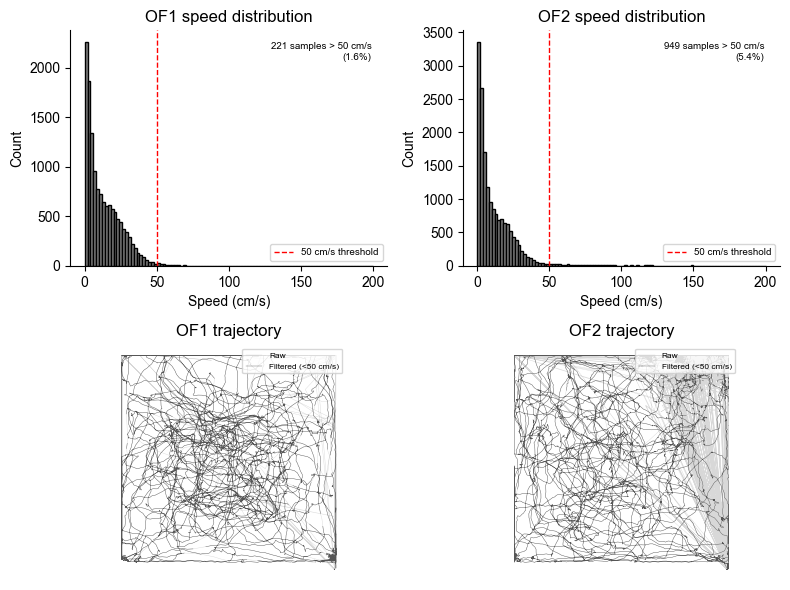

OF1: 949 bad samples (5.4%)


In [7]:
import numpy as np
import pynapple as nap
import matplotlib.pyplot as plt

SOURCE_PATH = '/Users/harryclark/Downloads/clark2025/'
mouse, day = 25, 24

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

for col, session in enumerate(['OF1', 'OF2']):
    folder = f'{SOURCE_PATH}M{mouse}/D{day:02}/{session}/'
    beh = nap.load_file(folder + f'sub-{mouse}_day-{day:02}_ses-{session}_beh.nwb')

    px = np.array(beh['P_x'])
    py = np.array(beh['P_y'])
    times = beh['P_x'].times()

    dt = np.diff(times)
    dx = np.diff(px)
    dy = np.diff(py)
    speed = np.sqrt(dx**2 + dy**2) / dt

    # Speed distribution
    ax = axes[0, col]
    ax.hist(speed, bins=100, range=(0, 200), color='grey', edgecolor='black', lw=0.3)
    ax.axvline(50, color='red', ls='--', lw=1, label='50 cm/s threshold')
    ax.set_xlabel('Speed (cm/s)')
    ax.set_ylabel('Count')
    ax.set_title(f'{session} speed distribution')
    ax.legend(fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)

    n_above = np.sum(speed > 50)
    ax.annotate(f'{n_above} samples > 50 cm/s\n({100*n_above/len(speed):.1f}%)',
                xy=(0.95, 0.95), xycoords='axes fraction', ha='right', va='top', fontsize=7)

    # Trajectory: raw vs filtered
    ax = axes[1, col]
    ax.plot(px, py, color='grey', lw=0.3, alpha=0.3, label='Raw')

    # Filter: NaN out positions where speed > 50 cm/s
    speed_full = np.concatenate([[0], speed])
    mask = speed_full < 50
    px_filt = px.copy()
    py_filt = py.copy()
    px_filt[~mask] = np.nan
    py_filt[~mask] = np.nan
    ax.plot(px_filt, py_filt, color='black', lw=0.3, alpha=0.6, label='Filtered (<50 cm/s)')

    ax.set_aspect('equal')
    ax.set_title(f'{session} trajectory')
    ax.legend(fontsize=6, loc='upper right')
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"OF1: {np.sum(speed > 50)} bad samples ({100*np.sum(speed > 50)/len(speed):.1f}%)")


## Sessions with multiple brain regions recorded simultaneously

For each session in `cell_classifications.csv` (same source used for the
region/cell-type analyses above), identify the set of distinct anatomical
regions recorded in that session -- i.e. sessions where the probe spanned
more than one brain area at once, giving simultaneous access to inter-area
activity rather than requiring separate recordings to compare regions.
Regions are grouped into coarse macro-areas first (MEC/PARA/PRE/HPF/CERE/
SUB/VIS); MEC is further split into superficial (ENTm1-3) and deep (ENTm5-6,
ENTl6a) sublayers as a secondary, finer-grained view -- multi-region here
means genuinely distinct brain areas, not just different layers of MEC.

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'

REGION_COLORS_MACRO = {'MEC': '#c04744', 'PARA': '#ff7f0e', 'PRE': '#2ca02c',
                        'HPF': '#17becf', 'CERE': '#8c564b', 'SUB': '#9467bd', 'VIS': '#1f77b4'}


def region_category_macro(r):
    if not isinstance(r, str):
        return 'OTHER'
    if r.startswith('VIS'):
        return 'VIS'
    if r.startswith('ENT'):
        return 'MEC'
    if r == 'PAR':
        return 'PARA'
    if r == 'PRE':
        return 'PRE'
    if r == 'HPF':
        return 'HPF'
    if r == 'CB':
        return 'CERE'
    if r == 'SUB':
        return 'SUB'
    return 'OTHER'


def region_category_fine(r):
    """Same as region_category_macro but splits MEC into superficial (ENTm1-3)
    and deep (ENTm5-6 / ENTl6a) sublayers."""
    if not isinstance(r, str):
        return 'OTHER'
    if r.startswith('VIS'):
        return 'VIS'
    if r.startswith('ENT'):
        m = re.search(r'(\d)', r)
        layer = m.group(1) if m else None
        if layer in ('1', '2', '3'):
            return 'ENTs'
        if layer in ('5', '6'):
            return 'ENTd'
        return 'OTHER'
    if r == 'PAR':
        return 'PARA'
    if r == 'PRE':
        return 'PRE'
    if r == 'HPF':
        return 'HPF'
    if r == 'CB':
        return 'CERE'
    if r == 'SUB':
        return 'SUB'
    return 'OTHER'


_cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_cc = _cc[_cc['mouse'] != 22].copy()
_cc['_region_macro'] = _cc['brain_region'].apply(region_category_macro)
_cc['_region_fine'] = _cc['brain_region'].apply(region_category_fine)

session_regions = (_cc[_cc['_region_macro'] != 'OTHER']
                    .groupby(['mouse', 'day'])['_region_macro']
                    .agg(lambda s: tuple(sorted(set(s)))))
session_regions = session_regions.reset_index(name='regions')
session_regions['n_regions'] = session_regions['regions'].apply(len)
session_regions = session_regions.sort_values(['n_regions', 'mouse', 'day'], ascending=[False, True, True])

n_multi = int((session_regions['n_regions'] >= 2).sum())
print(f'{len(session_regions)} sessions with >=1 categorized macro brain region (MEC/PARA/PRE/HPF/CERE/SUB/VIS)')
print(f'{n_multi} sessions ({n_multi/len(session_regions):.0%}) have >=2 distinct macro brain regions '
      f'recorded simultaneously')
print()
print('region-combination counts:')
print(session_regions['regions'].value_counts().to_string())
print()
print('multi-region sessions:')
print(session_regions[session_regions['n_regions'] >= 2].to_string(index=False))


69 sessions with >=1 categorized macro brain region (MEC/PARA/PRE/HPF/CERE/SUB/VIS)
23 sessions (33%) have >=2 distinct macro brain regions recorded simultaneously

region-combination counts:
regions
(MEC,)         37
(MEC, PARA)    19
(PARA,)         8
(HPF, MEC)      4
(CERE,)         1

multi-region sessions:
 mouse  day     regions  n_regions
  21.0 20.0  (HPF, MEC)          2
  21.0 21.0  (HPF, MEC)          2
  21.0 24.0  (HPF, MEC)          2
  21.0 26.0  (HPF, MEC)          2
  25.0 18.0 (MEC, PARA)          2
  25.0 19.0 (MEC, PARA)          2
  25.0 20.0 (MEC, PARA)          2
  25.0 21.0 (MEC, PARA)          2
  25.0 22.0 (MEC, PARA)          2
  25.0 24.0 (MEC, PARA)          2
  25.0 25.0 (MEC, PARA)          2
  26.0 15.0 (MEC, PARA)          2
  26.0 19.0 (MEC, PARA)          2
  27.0 18.0 (MEC, PARA)          2
  27.0 19.0 (MEC, PARA)          2
  28.0 17.0 (MEC, PARA)          2
  28.0 21.0 (MEC, PARA)          2
  28.0 23.0 (MEC, PARA)          2
  28.0 25.0 (MEC, PAR

Saved -> /Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/multiregion_session_combinations.pdf


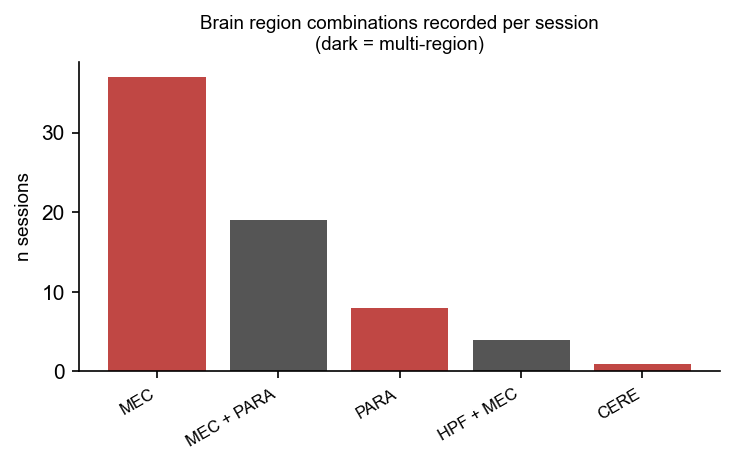

In [ ]:
combo_counts = session_regions['regions'].value_counts()
combo_labels = [' + '.join(c) for c in combo_counts.index]

fig, ax = plt.subplots(figsize=(5, 3.2))
bar_colors = ['#c04744' if len(c) == 1 else '#555555' for c in combo_counts.index]
ax.bar(range(len(combo_counts)), combo_counts.values, color=bar_colors)
ax.set_xticks(range(len(combo_counts)))
ax.set_xticklabels(combo_labels, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('n sessions', fontsize=9)
ax.set_title('Brain region combinations recorded per session\n(dark = multi-region)', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
out1 = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/multiregion_session_combinations.pdf'
plt.savefig(out1, bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved -> {out1}')


Best-balanced example multi-region session: M26D15 (MEC=57, PARA=63)
Saved -> /Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/multiregion_example_M26D15_anatomy.pdf


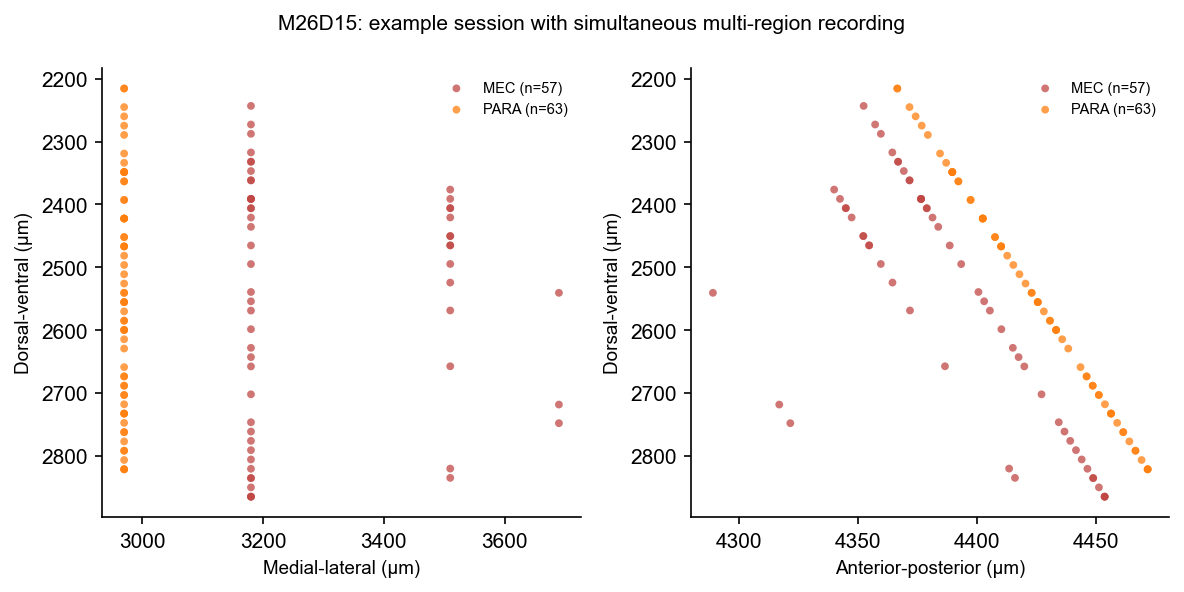

In [ ]:
sub = _cc[_cc['_region_macro'].isin(['MEC', 'PARA'])]
counts = sub.groupby(['mouse', 'day', '_region_macro']).size().unstack(fill_value=0)
counts = counts[(counts.get('MEC', 0) > 0) & (counts.get('PARA', 0) > 0)]
counts['min_n'] = counts[['MEC', 'PARA']].min(axis=1)
example_mouse, example_day = counts['min_n'].idxmax()
print(f'Best-balanced example multi-region session: M{int(example_mouse)}D{int(example_day)} '
      f'(MEC={int(counts.loc[(example_mouse, example_day), "MEC"])}, '
      f'PARA={int(counts.loc[(example_mouse, example_day), "PARA"])})')

ex = _cc[(_cc['mouse'] == example_mouse) & (_cc['day'] == example_day)].copy()
ex = ex[ex['_region_macro'] != 'OTHER'].dropna(subset=['SC_x', 'SC_y', 'SC_z'])
ex['ml'] = ex['SC_x'].abs()
ex['dv'] = ex['SC_y']
ex['ap'] = ex['SC_z']

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (xcol, xlabel) in zip(axes, [('ml', 'Medial-lateral (µm)'), ('ap', 'Anterior-posterior (µm)')]):
    for region in ex['_region_macro'].unique():
        r = ex[ex['_region_macro'] == region]
        ax.scatter(r[xcol], r['dv'], s=14, color=REGION_COLORS_MACRO.get(region, '#888888'),
                   label=f'{region} (n={len(r)})', alpha=0.75, edgecolor='none')
    ax.invert_yaxis()
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Dorsal-ventral (µm)', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=7, frameon=False)
fig.suptitle(f'M{int(example_mouse)}D{int(example_day)}: example session with simultaneous '
             f'multi-region recording', fontsize=10)
plt.tight_layout()
out2 = ('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/'
        f'multiregion_example_M{int(example_mouse)}D{int(example_day)}_anatomy.pdf')
plt.savefig(out2, bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved -> {out2}')


In [ ]:
session_regions_fine = (_cc[_cc['_region_fine'] != 'OTHER']
                         .groupby(['mouse', 'day'])['_region_fine']
                         .agg(lambda s: tuple(sorted(set(s)))))
session_regions_fine = session_regions_fine.reset_index(name='regions_fine')
session_regions_fine['n_regions_fine'] = session_regions_fine['regions_fine'].apply(len)
print('For reference, splitting MEC into superficial (ENTs, layers 1-3) and deep '
      '(ENTd, layers 5-6) sublayers:')
print(session_regions_fine['regions_fine'].value_counts().to_string())


For reference, splitting MEC into superficial (ENTs, layers 1-3) and deep (ENTd, layers 5-6) sublayers:
regions_fine
(ENTd, ENTs)          27
(ENTs,)               10
(ENTs, PARA)          10
(ENTd, ENTs, PARA)     9
(PARA,)                8
(ENTd, ENTs, HPF)      4
(CERE,)                1
